In [1]:
import os
os.getcwd()

'/home/achen918/cleave_real_targets/251222_tdp43_large_batch'

# Directory Structure

This directory contains scripts and folders to perform one round of rfd3=>EnhancedMPNN=>af3 for the design of zinc protease.

The home directory structure should look like this before start:
```
├── af3_complex_analysis
│   ├── collect_data.py
│   ├── convert_modify_pdb.py
│   ├── rmsd_calculation.py
├── af3_monomer_analysis
│   ├── collect_data.py
│   ├── convert_modify_pdb.py
│   ├── rmsd_calculation.py
├── filter_bb
│   ├── benchmark.py
├── motif_generation
│   ├── 251222_motif_with_ANISOU.pdb
└── round1_example.ipynb
```

# RFD3

## Epitope search

old version: 
After finding Pho-Xaa-Pho, put it at 7-8

current version:
expand the choice of cleavage site index in the 10-AA epitope
After finding Pho-Xaa-Pho, put it at indices 3-4, 4-5, 5-6, 6-7, 7-8 of chain B


In [4]:
### Clean up motif file
def remove_anisou(input_pdb, output_pdb):
    with open(input_pdb, "r") as infile, open(output_pdb, "w") as outfile:
        for line in infile:
            if not line.startswith("ANISOU"):
                outfile.write(line)

if __name__ == "__main__":
    input_pdb = os.getcwd() + "/motif/251222_motif_with_ANISOU.pdb"
    output_pdb = os.getcwd() + "/motif/251222_motif.pdb"
    remove_anisou(input_pdb, output_pdb)


In [2]:
### epitope libary `epitopes`: keys are the residue number of p1 (chain B residue before cleavage site.), values are epitope sequences
### for targets other than tdp, feel free to rename the epitope library to something else

# epitopes={}
# epitopes[7]="VVTGVTAVAQ"
# epitopes[]


window= "VVTGVTAVAQKTVE" ## fret substrate

# epitopes = {}
for i in range(5):
    epitopes[7-i] = window[i:i+10]
epitopes ## key: p1 residue number. value: epitope

{7: 'VVTGVTAVAQ',
 6: 'VTGVTAVAQK',
 5: 'TGVTAVAQKT',
 4: 'GVTAVAQKTV',
 3: 'VTAVAQKTVE'}

In [3]:
window= "GGAVVTGVTAVAQK" ## fret substrate

# epitopes = {}
for i in range(5):
    epitopes[7-i] = window[i:i+10]
epitopes ## key: p1 residue number. value: epitope

{7: 'GGAVVTGVTA',
 6: 'GAVVTGVTAV',
 5: 'AVVTGVTAVA',
 4: 'VVTGVTAVAQ',
 3: 'VTGVTAVAQK'}

## Create input pdbs for rfd3

This section creates a set of input pdbs for rfd3 in the `./motif_generation` folder. 

The input pdbs combines chain B residues + guide strand residues from Zn45_SZnO36, and the active site from 4qhp. The chain B residues other than p1 and p1' are initialized at 0.

The rfd3 input pdbs are named as follows:

epitope + p1_residue_index + p1prime_residue_index, for example: `QSSWGMMGML56.pdb` 

In [4]:
## flexible sequence input

from Bio.PDB import PDBParser, PDBIO, Atom, Residue, Chain, Model, Structure
import os
import numpy as np

# Three-letter amino acid codes
aa_three = {
    "A": "ALA","R":"ARG","N":"ASN","D":"ASP","C":"CYS",
    "E":"GLU","Q":"GLN","G":"GLY","H":"HIS","I":"ILE",
    "L":"LEU","K":"LYS","M":"MET","F":"PHE","P":"PRO",
    "S":"SER","T":"THR","W":"TRP","Y":"TYR","V":"VAL"
}
main_chain_atoms = ["N","CA","C","O"]
sidechain_atoms = {
    "ALA":["CB"], "ARG":["CB","CG","CD","NE","CZ","NH1","NH2"],
    "ASN":["CB","CG","OD1","ND2"], "ASP":["CB","CG","OD1","OD2"],
    "CYS":["CB","SG"], "GLU":["CB","CG","CD","OE1","OE2"],
    "GLN":["CB","CG","CD","OE1","NE2"], "GLY":[],
    "HIS":["CB","CG","ND1","CD2","CE1","NE2"], "ILE":["CB","CG1","CG2","CD1"],
    "LEU":["CB","CG","CD1","CD2"], "LYS":["CB","CG","CD","CE","NZ"],
    "MET":["CB","CG","SD","CE"], "PHE":["CB","CG","CD1","CD2","CE1","CE2","CZ"],
    "PRO":["CB","CG","CD"], "SER":["CB","OG"], "THR":["CB","OG1","CG2"],
    "TRP":["CB","CG","CD1","CD2","NE1","CE2","CE3","CZ2","CZ3","CH2"],
    "TYR":["CB","CG","CD1","CD2","CE1","CE2","CZ","OH"], "VAL":["CB","CG1","CG2"]
}

def mutate_chainB_pdb(input_pdb_path, 
                      peptide_seq, 
                      anchor_residue_num,
                      rfd_input_pdb_dir):
    """
    generates input pdb for rfd3 with chain A catalytic motif, Zn, P1 P1' bb atoms.
    ==================================================================================
    Args:
        input_pdb_path: Path to input PDB file
        peptide_seq: 10-letter sequence for new chain B
        anchor_residue_num: Residue number (1-indexed) in new chain B that will inherit
                           backbone coords from old residue 7. The next residue
                           (anchor_residue_num + 1) will inherit from old residue 8.
    """
    parser = PDBParser(QUIET=True)
    structure = parser.get_structure('model', input_pdb_path)
    
    # Extract main chain atom coords for the 7th and 8th residue in chain B
    chainB = structure[0]['B']
    res7_atoms = {a.get_name(): a.get_coord() for a in chainB[7] if a.get_name() in main_chain_atoms}
    res8_atoms = {a.get_name(): a.get_coord() for a in chainB[8] if a.get_name() in main_chain_atoms}
    
    # Build new structure
    new_structure = Structure.Structure("new")
    model = Model.Model(0)
    new_structure.add(model)
    
    # Copy chain A
    chainA = structure[0]['A']
    new_chainA = Chain.Chain('A')
    for res in chainA:
        new_res = Residue.Residue(res.id, res.get_resname(), res.segid)
        for atom in res:
            new_atom = Atom.Atom(
                atom.get_name(), atom.get_coord(), atom.get_bfactor(),
                atom.get_occupancy(), atom.get_altloc(), atom.get_fullname(),
                atom.get_serial_number(), element=atom.element
            )
            new_res.add(new_atom)
        new_chainA.add(new_res)
    model.add(new_chainA)
    
    # Copy chain C
    chainC = structure[0]['C']
    new_chainC = Chain.Chain('C')
    for res in chainC:
        new_res = Residue.Residue(res.id, res.get_resname(), res.segid)
        for atom in res:
            new_atom = Atom.Atom(
                atom.get_name(), atom.get_coord(), atom.get_bfactor(),
                atom.get_occupancy(), atom.get_altloc(), atom.get_fullname(),
                atom.get_serial_number(), element=atom.element
            )
            new_res.add(new_atom)
        new_chainC.add(new_res)
    model.add(new_chainC)
    
    # Make new chain B
    new_chainB = Chain.Chain('B')
    for i, aa in enumerate(peptide_seq):
        resname = aa_three[aa]
        res_num = i + 1  # 1-indexed residue number
        
        # Residue id: (' ', res_num, ' ')
        new_res = Residue.Residue((' ', res_num, ' '), resname, '')
        
        # Main chain atoms
        for at_name in main_chain_atoms:
            # Check if this residue should inherit coords from old chain B
            if res_num == anchor_residue_num and at_name in res7_atoms:
                coord = res7_atoms[at_name]
            elif res_num == anchor_residue_num + 1 and at_name in res8_atoms:
                coord = res8_atoms[at_name]
            else:
                coord = np.array([0.0, 0.0, 0.0])
            
            new_atom = Atom.Atom(
                at_name, coord, 90.0, 1.0, ' ', ' ' + at_name, i*1000,
                element=at_name[0] if at_name[0] in ['N','C','O'] else ''
            )
            new_res.add(new_atom)
        
        # Side chain atoms
        for at_name in sidechain_atoms[resname]:
            new_atom = Atom.Atom(
                at_name, np.array([0.0, 0.0, 0.0]), 90.0, 1.0, ' ', ' ' + at_name, i*1000 + 100,
                element=at_name[0] if at_name[0] in ['C','O','N','S'] else ''
            )
            new_res.add(new_atom)
        new_chainB.add(new_res)
    model.add(new_chainB)
    
    out_name = os.path.join(rfd_input_pdb_dir, peptide_seq + f"{anchor_residue_num}{anchor_residue_num+1}.pdb")
    io = PDBIO()
    io.set_structure(new_structure)
    io.save(out_name)
    print(f"Saved input pdb for rfd3: {out_name}")
    


In [5]:
input_pdb_path = os.getcwd() + "/motif_generation/251222_motif.pdb"
rfd_input_pdb_dir = os.getcwd() + "/motif_generation/rfd3_inputs"

for tdp_res in epitopes.keys():
    peptide_seq = epitopes[tdp_res]
    anchor_residue_num = tdp_res  ## anchored residue will end up being residue index anchor_residue_num in the output pdb
    mutate_chainB_pdb(input_pdb_path, peptide_seq, anchor_residue_num, rfd_input_pdb_dir)


Saved input pdb for rfd3: /home/achen918/cleave_real_targets/251222_tdp43_large_batch/motif_generation/rfd3_inputs/GGAVVTGVTA78.pdb
Saved input pdb for rfd3: /home/achen918/cleave_real_targets/251222_tdp43_large_batch/motif_generation/rfd3_inputs/GAVVTGVTAV67.pdb
Saved input pdb for rfd3: /home/achen918/cleave_real_targets/251222_tdp43_large_batch/motif_generation/rfd3_inputs/AVVTGVTAVA56.pdb
Saved input pdb for rfd3: /home/achen918/cleave_real_targets/251222_tdp43_large_batch/motif_generation/rfd3_inputs/VVTGVTAVAQ45.pdb
Saved input pdb for rfd3: /home/achen918/cleave_real_targets/251222_tdp43_large_batch/motif_generation/rfd3_inputs/VTGVTAVAQK34.pdb


## Sample ori

To enable some variability in rfd3's prior belief in the center of mass of the diffused protein, we sample the ori token in the plane right below Zn. The ori token is further sampled at run time using the `inference_sampler.s_jitter_origin=1` flag in the command. 

For more intro on ORI, check out `https://wiki.ipd.uw.edu/protocols/flow_matching_diffusion_aa_ppi`, the `centering` section and the `You have to specify the CoM` section. 

In [6]:
### calculate ori positions
### after running this, open ./motif_generation/circle_points.pdb  and  ./motif_generation/251222_motif.pdb in the same pymol session to check ori positions

import sys, os, math
from collections import namedtuple

Point = namedtuple("Point", ["x", "y", "z"])

base_dir = os.getcwd()
pdb_path = os.path.join(base_dir, "motif_generation", "251222_motif.pdb")
if not os.path.isfile(pdb_path):
    raise FileNotFoundError(f"Cannot find PDB: {pdb_path}")

# --- Helpers ---
def parse_pdb_atoms(path):
    atoms = []
    with open(path) as f:
        for line in f:
            if not (line.startswith("ATOM") or line.startswith("HETATM")):
                continue
            atom_name = line[12:16].strip()
            resname = line[17:20].strip()
            chain = line[21].strip() or " "
            resseq_raw = line[22:26].strip()
            try:
                resseq = int(resseq_raw)
            except:
                digits = ''.join([c for c in resseq_raw if c.isdigit()])
                resseq = int(digits) if digits else None
            try:
                x = float(line[30:38])
                y = float(line[38:46])
                z = float(line[46:54])
            except:
                continue
            element = line[76:78].strip().upper()
            if not element:
                nm = atom_name.strip()
                if nm and nm[0].isalpha():
                    element = nm[0].upper()
                elif len(nm) > 1:
                    element = nm[1].upper()
                else:
                    element = ""
            atoms.append({
                "atom_name": atom_name,
                "resname": resname,
                "chain": chain,
                "resseq": resseq,
                "x": x, "y": y, "z": z,
                "element": element,
                "line": line.rstrip()
            })
    return atoms


def find_atom_by(resnum, atom_name, resnames=None):
    cand = [a for a in atoms if a["atom_name"].upper() == atom_name.upper() and a["resseq"] == resnum]
    if cand:
        return cand[0]
    # relaxed +/- 3 residues
    for a in atoms:
        if a["atom_name"].upper() == atom_name.upper() and a["resseq"] and abs(a["resseq"] - resnum) <= 3:
            if resnames is None or a["resname"].upper() in [r.upper() for r in resnames]:
                return a
    return None


# --- Parse and locate atoms ---
atoms = parse_pdb_atoms(pdb_path)
a_h297_ne2 = find_atom_by(297, "NE2", resnames=["HIS", "HID", "HIE", "HIP"])
a_h293_ne2 = find_atom_by(293, "NE2", resnames=["HIS", "HID", "HIE", "HIP"])
a_e376_oe1 = find_atom_by(376, "OE1", resnames=["GLU"])

# find Zn on chain C, fallback to any Zn
zn_atom = None
for a in atoms:
    if a["chain"] == "C" and (a["element"] == "ZN" or a["atom_name"].upper() == "ZN" or a["resname"].upper() == "ZN"):
        zn_atom = a
        break
if zn_atom is None:
    for a in atoms:
        if a["element"] == "ZN" or a["atom_name"].upper() == "ZN" or a["resname"].upper() == "ZN":
            zn_atom = a
            break

missing = []
if a_h297_ne2 is None: missing.append("H297 NE2")
if a_h293_ne2 is None: missing.append("H293 NE2")
if a_e376_oe1 is None: missing.append("E316 OE1")
if zn_atom is None: missing.append("ZN (chain C preferred)")
if missing:
    print("ERROR: missing atoms:", missing)
    sys.exit(1)

p1 = Point(a_h297_ne2["x"], a_h297_ne2["y"], a_h297_ne2["z"])
p2 = Point(a_h293_ne2["x"], a_h293_ne2["y"], a_h293_ne2["z"])
p3 = Point(a_e376_oe1["x"], a_e376_oe1["y"], a_e376_oe1["z"])
zn = Point(zn_atom["x"], zn_atom["y"], zn_atom["z"])

# --- Geometry helpers ---
def sub(a, b): return (a.x - b.x, a.y - b.y, a.z - b.z)
def add(u, v): return (u[0] + v[0], u[1] + v[1], u[2] + v[2])
def scale(u, s): return (u[0] * s, u[1] * s, u[2] * s)
def dot(u, v): return u[0]*v[0] + u[1]*v[1] + u[2]*v[2]
def cross(u, v): return (u[1]*v[2] - u[2]*v[1], u[2]*v[0] - u[0]*v[2], u[0]*v[1] - u[1]*v[0])
def norm(u): return math.sqrt(dot(u, u))

# --- Define plane ---
v12 = sub(p2, p1)
v13 = sub(p3, p1)
n = cross(v12, v13)
n_norm = norm(n)
if n_norm == 0:
    raise ValueError("Atoms are collinear; plane undefined.")
n_unit = (n[0]/n_norm, n[1]/n_norm, n[2]/n_norm)
print("Plane normal (unit):", n_unit)

# --- Project Zn onto plane ---
# Equation of plane: n ⋅ (r - p1) = 0
# Projection: zn_proj = zn - n * (n⋅(zn - p1))
zn_vec = (zn.x, zn.y, zn.z)
p1_vec = (p1.x, p1.y, p1.z)
zn_to_plane_dist = dot(n_unit, (zn_vec[0]-p1_vec[0], zn_vec[1]-p1_vec[1], zn_vec[2]-p1_vec[2]))
zn_proj = (zn_vec[0] - n_unit[0]*zn_to_plane_dist,
           zn_vec[1] - n_unit[1]*zn_to_plane_dist,
           zn_vec[2] - n_unit[2]*zn_to_plane_dist)
center = Point(*zn_proj)
print("Projected Zn onto plane (circle center):", center)

# --- Create orthonormal basis (u,v) on plane ---
a_vec = (1.0, 0.0, 0.0)
if abs(dot(a_vec, n_unit)) > 0.9:
    a_vec = (0.0, 1.0, 0.0)
u = cross(n_unit, a_vec)
u_norm = norm(u)
u_unit = (u[0]/u_norm, u[1]/u_norm, u[2]/u_norm)
v = cross(n_unit, u_unit)
v_norm = norm(v)
v_unit = (v[0]/v_norm, v[1]/v_norm, v[2]/v_norm)

# --- Sample circle points ---
radius = 2.0
num = 9
pts = []
for k in range(num):
    theta = 2 * math.pi * k / num
    offset = add(scale(u_unit, radius * math.cos(theta)), scale(v_unit, radius * math.sin(theta)))
    pt = add((center.x, center.y, center.z), offset)
    pts.append(pt)
pts.append((center.x, center.y, center.z))

print("\nSampled 9 points (Index, X, Y, Z):")
for i, p in enumerate(pts, 1):
    print(f"{i:2d}: {p[0]:9.3f} {p[1]:9.3f} {p[2]:9.3f}")

# --- Output PDB ---
out = "motif_generation/circle_points.pdb"
with open(out, "w") as f:
    for i, p in enumerate(pts, 1):
        x, y, z = p
        f.write(f"HETATM{i:5d}  CTP CIR D {300+i:3d}    {x:8.3f}{y:8.3f}{z:8.3f}  1.00 90.00           C\n")
print("\nWrote:", os.path.abspath(out))
print("\nOpen:", os.path.abspath(out)," and ", pdb_path, "in the same pymol session to check ori positions")


Plane normal (unit): (-0.7492833706013767, 0.5307590320949603, -0.3960672675062418)
Projected Zn onto plane (circle center): Point(x=6.787079050497307, y=46.737634839647434, z=-4.442069319083505)

Sampled 9 points (Index, X, Y, Z):
 1:     6.787    45.542    -6.045
 2:     5.936    45.049    -5.094
 3:     5.483    45.347    -3.838
 4:     5.640    46.296    -2.864
 5:     6.334    47.451    -2.629
 6:     7.240    48.272    -3.242
 7:     7.934    48.376    -4.417
 8:     8.091    47.713    -5.603
 9:     7.638    46.593    -6.246
10:     6.787    46.738    -4.442

Wrote: /home/achen918/cleave_real_targets/251222_tdp43_large_batch/motif_generation/circle_points.pdb

Open: /home/achen918/cleave_real_targets/251222_tdp43_large_batch/motif_generation/circle_points.pdb  and  /home/achen918/cleave_real_targets/251222_tdp43_large_batch/motif_generation/251222_motif.pdb in the same pymol session to check ori positions


## Sample chain A contig

We have four groups of chain A motifs, and we only want a subset of all permutations. Therefore, we do this permutation mannually. If we want all permutations of all motifs, the rfd3 `unindex` entry in its json input can potentially do it.

In [8]:

## defining permutation

import itertools
import os



# the following are residue numbers for chain A motifs if Zn45 was used as the folding template in step 4. 
Y_motif = "A376-378"  # oxyanion stabilizer
E1_motif = "A315-317" # zinc-chelating residue
HEXXH_motif = "A293-297" # HEXXH
guidestrand_motif = "A28-30" # guidestrand


## define permutations
perm_YEs = [Y_motif, E1_motif] ## permute the tyrosine and the glutamate
perm_HBs = [HEXXH_motif, guidestrand_motif] ## permute the HEXXH helix and the edge strand beta sheet

contigs_chainA=[]
for perm_YE in itertools.permutations(perm_YEs):
    for perm_HB in itertools.permutations(perm_HBs):
        contigs_chainA.append(f"15-100,{perm_HB[0]},10-100,{perm_HB[1]},10-100,{perm_YE[0]},10-100,{perm_YE[1]},15-100")
        contigs_chainA.append(f"15-100,{perm_YE[0]},10-100,{perm_YE[1]},10-100,{perm_HB[0]},10-100,{perm_HB[1]},15-100")

contigs_chainA

['15-100,A293-297,10-100,A28-30,10-100,A376-378,10-100,A315-317,15-100',
 '15-100,A376-378,10-100,A315-317,10-100,A293-297,10-100,A28-30,15-100',
 '15-100,A28-30,10-100,A293-297,10-100,A376-378,10-100,A315-317,15-100',
 '15-100,A376-378,10-100,A315-317,10-100,A28-30,10-100,A293-297,15-100',
 '15-100,A293-297,10-100,A28-30,10-100,A315-317,10-100,A376-378,15-100',
 '15-100,A315-317,10-100,A376-378,10-100,A293-297,10-100,A28-30,15-100',
 '15-100,A28-30,10-100,A293-297,10-100,A315-317,10-100,A376-378,15-100',
 '15-100,A315-317,10-100,A376-378,10-100,A28-30,10-100,A293-297,15-100']

## Sample seeds

In [9]:
import random
seeds = random.sample(range(1, 10_000_000), 50)

## Build commands

In [10]:
# ============================
# Shared JSON template
# ============================

import os
import json
import glob

def write_json(input_pdb, 
               contig_A, 
               ori_token,
               contig_B_fixall = "B1-10"):
    input_pdb_name = os.path.basename(input_pdb).removesuffix(".pdb")    
    p1 = int(input_pdb_name[-2])
    contig_chainB = contig_B_fixall
    contig = contig_A + ",/0," + contig_chainB

    # build select_fixed_atoms
    select_fixed_atoms = {}
    for i in range(1, 11):  # B1 to B10
        if i == p1 or i == p1 + 1:
            select_fixed_atoms[f"B{i}"] = "BKBN"
        else:
            select_fixed_atoms[f"B{i}"] = ""

    template = {
        "global_args": {
            "redesign_motif_sidechains": False
        },
        "des": {
            "input": input_pdb,
            "contig": contig,
            "length": "170-200",
            "ligand": "ZO",
            "select_unfixed_sequence": "A28-A30,A295-296,A376,A378,A315,A317",
            "select_hotspots": "B3-7",
            "select_fixed_atoms": select_fixed_atoms,
            "ori_token": ori_token
        }
    }

    return template


# ============================
# Make all JSONs + commands
# ============================

output_dir = "/net/scratch/achen918/cleave_real_targets/251222_tdp43_large_batch/rfd3/output"
commands_output_file = "/net/scratch/achen918/cleave_real_targets/251222_tdp43_large_batch/rfd3/cmd"
input_json_dir = "/net/scratch/achen918/cleave_real_targets/251222_tdp43_large_batch/rfd3/input_json"
rfd3_input_pdb_dir = os.getcwd() + "/motif_generation/rfd3_inputs"
rfd3_input_pdbs = glob.glob(rfd3_input_pdb_dir + "/*.pdb")
os.makedirs(output_dir,exist_ok=True)
os.makedirs(input_json_dir,exist_ok=True)

commands = []
diffusion_batch_size=4 
n_batches=5

for rfd3_input_pdb in rfd3_input_pdbs:
    rfd3_input_pdb_name = os.path.basename(rfd3_input_pdb).removesuffix(".pdb")    
    for k, seed in enumerate(seeds,start=1):
        for j,ori in enumerate(pts,start=1):
            for i, contig_A in enumerate(contigs_chainA, start=1):
                json_filename = f"{rfd3_input_pdb_name}_ori{j}_contig{i}_seed{k}.json"
                json_path = os.path.join(input_json_dir, json_filename)

                # Fill JSON content
                data = write_json(rfd3_input_pdb, 
                       contig_A, 
                       ori_token=ori,
                       contig_B_fixall = "B1-10")

                # Save JSON
                with open(json_path, "w") as f:
                    json.dump(data, f, indent=2)

                # Build command
                cmd = (
                    f"apptainer exec --env PROJECT_PATH=/projects/ml/aa_design/repos/aa_design_main/projects/aa_design "
                    f"--nv /projects/ml/aa_design/repos/aa_design_main/scripts/shebang/modelhub.sif "
                    f"/home/achen918/software/modelhub/src/modelhub/inference.py "
                    f"out_dir={output_dir} "
                    f"ckpt_path=/projects/ml/aa_design/models/rfd3_latest.ckpt "
                    f"inputs={json_path} "
                    f"diffusion_batch_size={diffusion_batch_size} n_batches={n_batches} skip_existing=True cleanup_virtual_atoms=True "
                    f"print_config=True dump_trajectories=False inference_sampler.s_jitter_origin=1 seed={seed}"
                )

                commands.append(cmd)

# Write all commands to file
with open(commands_output_file, "w") as f:
    for c in commands:
        f.write(c + "\n")
print(f"Generated {len(commands)} JSON files in:")
print("  ", input_json_dir)
print(f"Wrote all commands to:\n  {commands_output_file}")


Generated 32000 JSON files in:
   /net/scratch/achen918/cleave_real_targets/251222_tdp43_large_batch/rfd3/input_json
Wrote all commands to:
  /net/scratch/achen918/cleave_real_targets/251222_tdp43_large_batch/rfd3/cmd


## Prepare RFD3 array job submission script

In [11]:
## Must use HETATM for zinc for the commands to work
# Number of commands per job
import math
tasks_per_job = 100 ## 200 partial diffusion tasks, 28 cmds for each. => 2 h 5 k bb, 2 h, 200 gpus => 50 k bb. 

# on average 1.5 min per bb, for 10 designs per 
 
# Calculate the number of array jobs needed
number_of_runs = math.ceil(len(commands) / tasks_per_job)
scratch_dir = "/net/scratch/achen918/cleave_real_targets/251222_tdp43_large_batch/"
working_dir  = scratch_dir+ "/rfd3"
cmd_path = "/net/scratch/achen918/cleave_real_targets/251222_tdp43_large_batch/rfd3/cmd"

log_dir =working_dir  +  "/log"
os.makedirs(log_dir,exist_ok=True)

# SLURM submission script template
submit_script = f"""#!/bin/bash
#SBATCH -p gpu-bf
#SBATCH --gres=gpu:1
#SBATCH --mem=16g
#SBATCH -c 1
#SBATCH -o {log_dir}/out.log%a
#SBATCH -t 05:00:00
#SBATCH --mail-type=BEGIN
#SBATCH --mail-type=END
#SBATCH --mail-user=achen918
#SBATCH --exclude=g1103,g1104,g1105,g1106,g1107,g1108,g1109,g1110,g1111,g1112,g1113,g1114,g1115,g1116,g1117,g1118,g1119,g1120,g1121,g1122,g1123,g1124,g2117,g2702,g2703,g2705
#SBATCH -a 1-{number_of_runs}

# Get the starting task index for the job
start=$(( (SLURM_ARRAY_TASK_ID - 1) * {tasks_per_job} + 1 ))
# Calculate the ending task index for this job
end=$(( start + {tasks_per_job} - 1 ))

# Loop through the tasks for this job
for i in $(seq $start $end); do
    CMD=$(sed -n "${{i}}p" {cmd_path})
    # If CMD is empty (because we reached the end of the file), break the loop
    [ -z "${{CMD}}" ] && break
    # Run the command
    echo "Running task $i: ${{CMD}}"
    echo "${{CMD}}" | bash
done
"""

# Save the SLURM submission script
submit_file_path = os.path.join(working_dir, 'submit_rfd3.sh')
with open(submit_file_path, 'w') as f:
    f.write(submit_script)

print(f"SLURM submit script saved to {submit_file_path}")

SLURM submit script saved to /net/scratch/achen918/cleave_real_targets/251222_tdp43_large_batch//rfd3/submit_rfd3.sh


In [12]:
### test this on an interactive gpu node with > 16 g memory `qlogin -p gpu --gres=gpu:a4000:1 --mem=16g`
print(cmd)

apptainer exec --env PROJECT_PATH=/projects/ml/aa_design/repos/aa_design_main/projects/aa_design --nv /projects/ml/aa_design/repos/aa_design_main/scripts/shebang/modelhub.sif /home/achen918/software/modelhub/src/modelhub/inference.py out_dir=/net/scratch/achen918/cleave_real_targets/251222_tdp43_large_batch/rfd3/output ckpt_path=/projects/ml/aa_design/models/rfd3_latest.ckpt inputs=/net/scratch/achen918/cleave_real_targets/251222_tdp43_large_batch/rfd3/input_json/VVTGVTAVAQ45_ori10_contig8_seed50.json diffusion_batch_size=4 n_batches=5 skip_existing=True cleanup_virtual_atoms=True print_config=True dump_trajectories=False inference_sampler.s_jitter_origin=1 seed=4108949


# Benchmark bb

Filter rfd3 output based on backbone quality

In [245]:
import argparse
import os
import math
import glob

def create_slurm_script(script_path, csv_file, bb_dir, temp_pdb_outdir, num_jobs, cif_gzs_per_job,log_dir,out_dir):
    """
    need to use the universal.sif container, which has gcc 13 version, consistent with its build on local linux, because of dssp `https://github.com/PDB-REDO/dssp`
    """
    script = f"""#!/bin/bash
#SBATCH -p cpu
#SBATCH --mem=16g
#SBATCH -c 1
#SBATCH -J benchmarl_bb
#SBATCH -o {log_dir}/out.log%a
#SBATCH -t 00:30:00
#SBATCH -a 1-{num_jobs}

# Calculate start and end indices for this job
start_idx=$(( ($SLURM_ARRAY_TASK_ID - 1) * {cif_gzs_per_job} + 1 ))
end_idx=$(( $SLURM_ARRAY_TASK_ID * {cif_gzs_per_job} ))

# Create a temporary directory for this job
temp_dir="{out_dir}/tmp/$SLURM_JOB_ID"
mkdir -p $temp_dir

# Process the subset of cif_gzs for this job
/software/containers/universal.sif {script_path} $temp_dir/output_$SLURM_ARRAY_TASK_ID.csv "{bb_dir}" "{temp_pdb_outdir}" --start $start_idx --end $end_idx

"""
    return script



scratch_dir =  "/net/scratch/achen918/cleave_real_targets/251222_tdp43_large_batch"
working_dir = scratch_dir + "/filter_bb"
os.makedirs(working_dir,exist_ok=True)
temp_pdb_outdir = working_dir + "/temp_pdbs_for_dssp"
os.makedirs(temp_pdb_outdir,exist_ok=True)
csv_file = working_dir + "/benchmark.csv"
out_dir = working_dir +"/parallel_benchmark"
os.makedirs(out_dir,exist_ok=True)
bb_dir = scratch_dir +"/rfd3/output"
log_dir = working_dir +"/log"
os.makedirs(log_dir,exist_ok=True)
script_path = os.getcwd()+"/filter_bb/benchmark.py"
submit_script = os.getcwd()+"/filter_bb/submit_benchmark.sh"
num_cif_gzs = len(glob.glob(bb_dir + "/*.cif.gz"))
print(f"found {num_cif_gzs} cif.gzs")
cif_gzs_per_job = 100
num_jobs = math.ceil(num_cif_gzs /cif_gzs_per_job )
script = create_slurm_script(script_path,
                             csv_file, 
                             bb_dir, 
                             temp_pdb_outdir,
                             num_jobs, 
                             cif_gzs_per_job,
                             log_dir,
                             out_dir)

with open(submit_script, "w") as f:
    f.write(script)

print(f"SLURM submit: sbatch {submit_script}")


found 37629 cif.gzs
SLURM submit: sbatch /home/achen918/cleave_real_targets/251222_tdp43_large_batch/filter_bb/submit_benchmark.sh


In [246]:
scratch_dir =  "/net/scratch/achen918/cleave_real_targets/251222_tdp43_large_batch"
working_dir = scratch_dir + "/filter_bb"
csv_file = working_dir + "/benchmark.csv"
out_dir = working_dir + "/parallel_benchmark/tmp"
concatenating_command = f"cat {out_dir}/*/output_*.csv > {csv_file}"
print('concatenate all processed csv files:\n',concatenating_command)
print('\nIf you see *~ files, simply check the .csv file and do rm *~')
print("\nremove temporary pdb dir: rm -r ", temp_pdb_outdir)

concatenate all processed csv files:
 cat /net/scratch/achen918/cleave_real_targets/251222_tdp43_large_batch/filter_bb/parallel_benchmark/tmp/*/output_*.csv > /net/scratch/achen918/cleave_real_targets/251222_tdp43_large_batch/filter_bb/benchmark.csv

If you see *~ files, simply check the .csv file and do rm *~

remove temporary pdb dir: rm -r  /net/scratch/achen918/cleave_real_targets/251222_tdp43_large_batch/filter_bb/temp_pdbs_for_dssp


In [247]:
### analyze benchmark
import os
import pandas as pd
def has_consecutive(sequence, char, count):
    """
    Function to check if there are more than a specified number of a character in a row
    """
    return char * count in sequence[:-10]
    
pd.set_option('display.max_colwidth', None)
csv_file = working_dir + "/benchmark.csv"
df = pd.read_csv(csv_file)
df=df[df["file_name"]!="file_name"].reset_index(drop=True)
df["file_path"] = df["file_path"]
df["long_loop"] = df["dssp_sequence"].apply(lambda x: has_consecutive(x, 'L', 10))
df.iloc[-5:]


,file_name,H,S,L,X,dssp_sequence,floating_sidechain,chain_break,largest_opening_angle,bb_clashes,sc_clashes,file_path,long_loop
38574,QSSWGMMGML56_ori8_contig6_seed44_des_29_model_2.cif.gz,0.5634517766497462,0.06091370558375635,0.34517766497461927,0.030456852791878174,LHHHHHHHHHHHHHHHHHHHHHLLLHHHHHHHHHHHHHLLLLLLHHHHHHHHHHHHHHHHHHHHHHLLLLLHHHHHHHHHHHHHHHHHHLLLXXXXXLLLLXLLLLLLLLSSSSLLHHHLLHHHHHHHHHHHHHHHLLLLLLHHHHHHHHHHLLLLSSLLLLLLLLSSSSSSLLHHHHHHHHHLLLLLLLLLLLLLL,False,False,4.985545241737206,0,4,/net/scratch/achen918/cleave_real_targets/251222_tdp43_large_batch/rfd3/output/QSSWGMMGML56_ori8_contig6_seed44_des_29_model_2.cif.gz,False
38575,QSSWGMMGML56_ori8_contig6_seed44_des_29_model_3.cif.gz,0.5989847715736041,0.15736040609137056,0.22842639593908629,0.015228426395939087,LHHHHHHHHHHHHHHLLLHHHHHHHHHHHHHHLHHHHHHHHHHHLLLLLHHHHHHHHHHHHHHHHHHHLHHHHHHHHHLLXXSSSSSSSSHHHHHHHHLLLLLLLLHHHHHHHHHHHHHHLHHHHHHHHHHHHHHLLLLSSSHHHHHHHHHHHHLLLSSSSSSSLLLSSSSSSLLLLLHHHLLSSXLLLLSSSSSLL,False,False,4.490422512784511,0,5,/net/scratch/achen918/cleave_real_targets/251222_tdp43_large_batch/rfd3/output/QSSWGMMGML56_ori8_contig6_seed44_des_29_model_3.cif.gz,False
38576,QSSWGMMGML56_ori8_contig6_seed44_des_31_model_0.cif.gz,0.5482233502538071,0.14720812182741116,0.2893401015228426,0.015228426395939087,LLLHHHLLLLLSSSSXXXLLLLLHHHHHHHHHHHHHHLLLLHHHHHHHHHHHHHHHHHHHLLLLLLHHHHHHHHHHHHHHHLLLLLLHHHHHHLLHHHHHHHHHHHHHHHHHHHHHHHHLLLLLLLLLLHHHHHHHHHHHHHHHHHLLLLLLLSSSSSSSSLLLLLSSSSSSSSSLHHHHHHHHHHLLSSSSSSSSL,False,False,5.1196463786283175,0,0,/net/scratch/achen918/cleave_real_targets/251222_tdp43_large_batch/rfd3/output/QSSWGMMGML56_ori8_contig6_seed44_des_31_model_0.cif.gz,True
38577,QSSWGMMGML56_ori8_contig6_seed44_des_31_model_1.cif.gz,0.6395939086294417,0.1218274111675127,0.23857868020304568,0.0,LLHHHHHHHHHHHHHHHHHHHHHLLHHHHHHHHHLLLLHHHHHHHHHHHHHHHHHHHHHHHHLHHHHHHLHHHHHHHHHHHHHHLHHHHHHHHHHLLLHHHHHHHHHHHHHHHHHHHLLLLLLHHHLLHHHHHHHHHHHHHHHHHHHHLLLLLSSSSSSSSSLLLLLSSSSSSSSLLLLSSSSLLLLLSSSLLLLLL,False,False,4.122511051627174,0,0,/net/scratch/achen918/cleave_real_targets/251222_tdp43_large_batch/rfd3/output/QSSWGMMGML56_ori8_contig6_seed44_des_31_model_1.cif.gz,False
38578,QSSWGMMGML56_ori8_contig6_seed44_des_31_model_2.cif.gz,0.6142131979695431,0.13705583756345177,0.2233502538071066,0.025380710659898477,LXXXXXHHHHHHHHHHLSSLLLHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHLHHHHHLLLLHHHHHHHHHHHHHHHHHHHLLLLLLLHHHHHHHHHLLLLHHHHHHHHHHLLLHHHHHHHHHHHHHHHHHHHHHHHLLLLLSSSSSSSSSLLLLSSSSSSSSSLLHHHHLLLLLLLSSSSSSSLL,False,False,6.066879401950223,0,0,/net/scratch/achen918/cleave_real_targets/251222_tdp43_large_batch/rfd3/output/QSSWGMMGML56_ori8_contig6_seed44_des_31_model_2.cif.gz,False


In [248]:
## filter

import os
import shutil
import glob
import gzip
from Bio.PDB import MMCIFParser, PDBIO

filtered_bb_dir = working_dir +"/filtered_bbs"
# Create the destination folder if it doesn't exist
os.makedirs(filtered_bb_dir , exist_ok=True)

largest_opening_angle_thresh = 25 ## only keep backbones if the topological opening angle is > 25 degree, allowing the substrate peptide to easily access

# if more than 1 job in benchmark bb job
condition = (df["chain_break"] == "False")  &\
            (df["floating_sidechain"] == "False") & \
            (df["long_loop"] == False) & \
            (df["bb_clashes"] == "0") & \
            (df["sc_clashes"] == "0") & \
            (df["largest_opening_angle"].apply(lambda x: float(x)> largest_opening_angle_thresh)) 


print(f"number of passing designs: {len(df[condition])}")


# Make sure output dir exists
os.makedirs(filtered_bb_dir, exist_ok=True)

parser = MMCIFParser(QUIET=True)
io = PDBIO()

for i, file_path in enumerate(df[condition]['file_path']):
    # Derive filenames
    base_prefix = os.path.basename(file_path).replace(".cif.gz", "")
    pdb_name = base_prefix + ".pdb"
    json_name = base_prefix + ".json"
    dest_pdb = os.path.join(filtered_bb_dir, pdb_name)
    dest_json = os.path.join(filtered_bb_dir, json_name)

    # Skip conversion if the pdb already exists
    if not os.path.exists(dest_pdb):
        # Convert CIF→PDB
        with gzip.open(file_path, "rt") as handle:
            structure = parser.get_structure(base_prefix, handle)
        io.set_structure(structure)
        io.save(dest_pdb)

    # Copy corresponding JSON if available
    json_path = file_path.replace(".cif.gz", ".json")
    if os.path.exists(json_path) and not os.path.exists(dest_json):
        shutil.copy(json_path, dest_json)
    elif not os.path.exists(json_path):
        print(f"⚠️ Warning: JSON not found for {file_path}")

    # Print progress
    if i % 100 == 0:
        print(f"{i} files processed (PDB + JSON).")

# Final count
num_pdbs = len(glob.glob(f"{filtered_bb_dir}/*.pdb"))
num_jsons = len(glob.glob(f"{filtered_bb_dir}/*.json"))
print(f"{num_pdbs} PDB files and {num_jsons} JSON files now in {filtered_bb_dir}.")



number of passing designs: 4420
0 files processed (PDB + JSON).
100 files processed (PDB + JSON).
200 files processed (PDB + JSON).
300 files processed (PDB + JSON).
400 files processed (PDB + JSON).
500 files processed (PDB + JSON).
600 files processed (PDB + JSON).
700 files processed (PDB + JSON).
800 files processed (PDB + JSON).
900 files processed (PDB + JSON).
1000 files processed (PDB + JSON).
1100 files processed (PDB + JSON).
1200 files processed (PDB + JSON).
1300 files processed (PDB + JSON).
1400 files processed (PDB + JSON).
1500 files processed (PDB + JSON).
1600 files processed (PDB + JSON).
1700 files processed (PDB + JSON).
1800 files processed (PDB + JSON).
1900 files processed (PDB + JSON).
2000 files processed (PDB + JSON).
2100 files processed (PDB + JSON).
2200 files processed (PDB + JSON).
2300 files processed (PDB + JSON).
2400 files processed (PDB + JSON).
2500 files processed (PDB + JSON).
2600 files processed (PDB + JSON).
2700 files processed (PDB + JSON).


<Axes: xlabel='largest_opening_angle', ylabel='Count'>

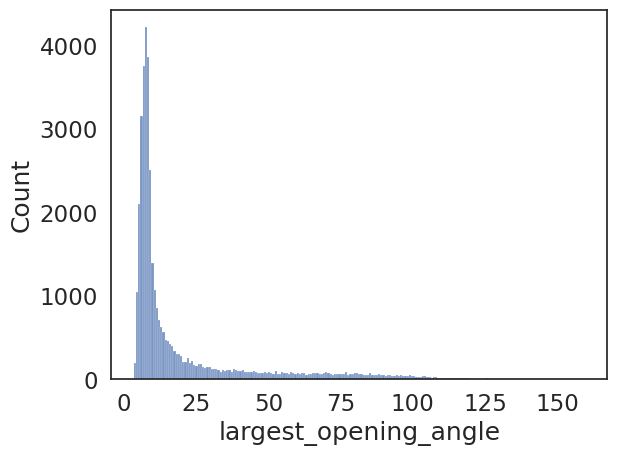

In [249]:
## visualize the distribution of the largest opening angle
import seaborn as sns
df["largest_opening_angle"] = df["largest_opening_angle"].apply(lambda x: float(x))
sns.histplot(data = df,
             x = "largest_opening_angle")

# EnhancedMPNN

In [147]:
# === Standard Library ===
import os
import sys
import glob
import json
from multiprocessing import Pool, cpu_count
from collections import defaultdict
import fnmatch

# === Third-Party Libraries ===
import numpy as np
import pandas as pd

# === BioPython ===
from Bio import PDB                     # uses PDBParser through PDB.PDBParser
from Bio.PDB import Superimposer        # you imported but did not use in your code

# === Gzip ===
import gzip

parser = PDB.PDBParser(QUIET=True) ## do not remove

def extract_residue_numbers(template_pdb_path,
                            chain_id = "A",
                            his1 = 293,
                            his2 = 297,
                            glu1 = 294,
                            glu2 = 316, 
                            tyr = 377):
    """
    input: path of the template pdb from filtered diffusion outcome.
    output: tuple which contains: list of three histidine residue id and four integers.
    """
    structure = parser.get_structure('template', template_pdb_path)
    zinc = next(structure[0]['C'].get_residues()).get_id()[1]  
    
    # --- Load JSON metadata ---
    json_path = template_pdb_path.replace(".pdb", ".json")
    if not os.path.exists(json_path):
        raise FileNotFoundError(f"JSON file not found for {template_pdb_path}")

    with open(json_path, "r") as f:
        data = json.load(f)

    # --- Helper: parse diffused index map ---
    diff_map = data.get("diffused_index_map", {})

    def get_index_for(key):
        """Return integer part of diffused_index_map value for a given key like 'A76'."""
        val = diff_map.get(key)
        if val is None:
            raise KeyError(f"Missing key '{key}' in diffused_index_map from {json_path}")
        try:
            return int(val[1:])  # remove chain letter (e.g. 'A') and convert to int
        except Exception as e:
            raise ValueError(f"Invalid mapping value '{val}' for key '{key}' in {json_path}: {e}")

    # --- Extract catalytic residues ---
    his_residues = [get_index_for(chain_id + str(his1)), get_index_for(chain_id + str(his2))]
    tyr_residue = get_index_for(chain_id + str(tyr))
    glu_residues = [get_index_for(chain_id + str(glu1)), get_index_for(chain_id + str(glu2))]
    

    if (len(his_residues)==2) and (len(glu_residues)==2) and tyr_residue:
        # print(f"found all residues for {template_pdb_path}")
        return his_residues, glu_residues, tyr_residue


def write_mpnn_cmd(pdb_path, 
                   fixed_residues,
                   output_folder, 
                   temperature,
                   batch_size = 10,
                   number_of_batches = 1):
    """
    Generate the MPNN command string.
    """
    
    
    command = (
        f"/usr/bin/singularity exec /software/containers/mlfold.sif python /databases/mpnn/fused_mpnn/run.py "
        f"--model_type ligand_mpnn "
        f"--pdb_path {pdb_path} "
        f"--out_folder \"{output_folder}\" "
        f"--fixed_residues \"{fixed_residues}\" "
        f"--batch_size {batch_size} "
        f"--number_of_batches {number_of_batches} "
        f"--temperature {temperature} "
        f"--omit_AA CH "
        f"--chains_to_design A "
        f"--pack_side_chains 0 "
        f"--enhance plddt_16_20240910-b65a33eb"
        f"\n"
    )
    return command

scratch_dir = "/net/scratch/achen918/cleave_real_targets/251222_tdp43_large_batch"
bb_dir = scratch_dir + "/filter_bb/filtered_bbs"
working_dir = scratch_dir + "/enhanced_mpnn"
output_folder = working_dir + "/enhanced_mpnn_out"
rfd_output_dir = scratch_dir + "/rfd3/output"

os.makedirs(working_dir,exist_ok=True)

pdb_paths = glob.glob(bb_dir  + "/*.pdb")
print("Number of scaffolds to design_seqs for is:")
print(len(pdb_paths))

# File path for the output command list
command_file_path = os.path.join(working_dir, 'cmds_enhanced_mpnn')

# Open the command file for writing
with open(command_file_path, 'w') as cmd_file:
    for idx,pdb_path in enumerate(pdb_paths):
        
        
        pdb_file = os.path.basename(pdb_path)
        pdb_name = pdb_file.replace('.pdb', '')
        
        hises,glus,tyr =  extract_residue_numbers(pdb_path)
        fixed_residues_individuals = hises+ glus + [tyr]
        fixed_residues = " ".join(["A" + str(res) for res in fixed_residues_individuals])
        
        # Write the command to the file
        for temperature,temperature_tag in zip([0.1],["0p1"]):
            output_folder = os.path.join(working_dir, 'enhanced_mpnn_output', pdb_name)# + f"_{temperature_tag}"
            os.makedirs(output_folder, exist_ok=True)
            
            cmd = write_mpnn_cmd(pdb_path, 
                                 fixed_residues,
                                 output_folder, 
                                 temperature,
                                 batch_size = 10)

            cmd_file.write(cmd)
        if idx %10 ==0:
            print(f"processed {idx} out of {len(pdb_paths)} files")
print(f"run: sbatch {command_file_path}")

Number of scaffolds to design_seqs for is:
61
/net/scratch/achen918/cleave_real_targets/251222_tdp43_large_batch/filter_bb/filtered_bbs/LQSSWGMMGM67_ori3_contig7_seed2_des_0_model_0.pdb
A104 A108 A105 A144 A159
processed 0 out of 61 files
/net/scratch/achen918/cleave_real_targets/251222_tdp43_large_batch/filter_bb/filtered_bbs/ALQSSWGMMG78_ori8_contig5_seed8_des_0_model_0.pdb
A93 A97 A94 A161 A174
/net/scratch/achen918/cleave_real_targets/251222_tdp43_large_batch/filter_bb/filtered_bbs/QSSWGMMGML56_ori5_contig2_seed2_des_0_model_0.pdb
A141 A145 A142 A105 A27
/net/scratch/achen918/cleave_real_targets/251222_tdp43_large_batch/filter_bb/filtered_bbs/ALQSSWGMMG78_ori1_contig7_seed5_des_0_model_0.pdb
A97 A101 A98 A154 A169
/net/scratch/achen918/cleave_real_targets/251222_tdp43_large_batch/filter_bb/filtered_bbs/QSSWGMMGML56_ori3_contig7_seed7_des_0_model_0.pdb
A109 A113 A110 A149 A163
/net/scratch/achen918/cleave_real_targets/251222_tdp43_large_batch/filter_bb/filtered_bbs/QSSWGMMGML56_ori1

In [148]:
# === Input your variables here ===
cmd_file = os.path.join(working_dir, 'cmds_enhanced_mpnn')
log_dir = os.path.join(working_dir, 'log')
os.makedirs(log_dir, exist_ok=True)
slurm_script_path = os.path.join(working_dir, "run_enhanced_mpnn_array.sh")
job_name = "enhanced_mpnn"
partition = "cpu"
mem = "32G"
time = "01:00:00"

# How many commands per array job
chunk_size = 5

# === Count number of lines in command file ===
with open(cmd_file) as f:
    lines = [line for line in f if line.strip()]  # non-empty only
num_jobs = len(lines)

# Compute number of array tasks needed
num_array_tasks = (num_jobs + chunk_size - 1) // chunk_size  # ceil division

# === SLURM script content ===
slurm_script = f"""#!/bin/bash
#SBATCH -p {partition}
#SBATCH --mem={mem}
#SBATCH -c 1
#SBATCH -J {job_name}
#SBATCH -o {log_dir}/{job_name}_%A_%a.out
#SBATCH -t {time}
#SBATCH -a 0-{num_array_tasks - 1}

# Calculate start and end line numbers for this task
start=$(( SLURM_ARRAY_TASK_ID * {chunk_size} + 1 ))
end=$(( start + {chunk_size} - 1 ))

echo "Running commands from line $start to $end"

# Run each command in this block
for i in $(seq $start $end); do
    cmd=$(sed -n "${{i}}p" {cmd_file})
    if [ -n "$cmd" ]; then
        echo ">>> Executing: $cmd"
        eval "$cmd"
    fi
done
"""

# === Write to file ===
with open(slurm_script_path, "w") as f:
    f.write(slurm_script)

print(f"✅ Created SLURM array script with {num_array_tasks} array tasks, {slurm_script_path}, processing {chunk_size} commands each.")


✅ Created SLURM array script with 13 array tasks, /net/scratch/achen918/cleave_real_targets/251222_tdp43_large_batch/enhanced_mpnn/run_enhanced_mpnn_array.sh, processing 5 commands each.


# AF3 monomer

This AF3 version 

1. Bins sequences with the same length.

2. Compiles the af3 model only once before all seqs in this length group are predicted.

3. Contains a checkpoint for repeated jobs, allowing jobs to be submitted to the gpu-bf queue.

copy `/home/achen918/software/run_alphafold_custom.py` to somewhere in your home dir, and run af3 using this `run_alphafold_custom.py` script in indrek's container `/software/containers/users/ikalvet/mlfold3/mlfold3_01.sif python`

In [151]:
import os
import glob
import json
from Bio.PDB import MMCIFParser
from Bio.PDB import PDBParser



# Amino acid mapping from 3-letter to 1-letter code
aa_map = {
    "ALA": "A", "ARG": "R", "ASN": "N", "ASP": "D", "CYS": "C",
    "GLN": "Q", "GLU": "E", "GLY": "G", "HIS": "H", "ILE": "I",
    "LEU": "L", "LYS": "K", "MET": "M", "PHE": "F", "PRO": "P",
    "SER": "S", "THR": "T", "TRP": "W", "TYR": "Y", "VAL": "V"
}


def extract_sequence_from_pdb(pdb_file, chain_id):
    """Extracts the sequence of a given chain from a PDB file."""
    sequence = []
    seen_residues = set()

    with open(pdb_file, 'r') as file:
        for line in file:
            if line.startswith("ATOM") and line[21] == chain_id:  # Column 22 is Chain ID
                res_name = line[17:20].strip()  # Column 18-20 is Residue Name
                res_id = line[22:26].strip()    # Column 23-26 is Residue Number
                
                if (res_id not in seen_residues) and (res_name in aa_map):
                    seen_residues.add(res_id)
                    sequence.append(aa_map[res_name])
    
    return "".join(sequence)


# Define directories

scratch_dir = "/net/scratch/achen918/cleave_real_targets/251222_tdp43_large_batch"
working_dir = scratch_dir + "/af3_monomer"
input_dir = scratch_dir + "/enhanced_mpnn/enhanced_mpnn_output/*/backbones/" # all mpnn seqs are used
json_dir = f'{working_dir}/json_files'
output_dir = working_dir + '/output'
command_file_path = os.path.join(working_dir, "cmds_af3_monomer")

# Ensure directories exist
os.makedirs(working_dir, exist_ok=True)
os.makedirs(json_dir, exist_ok=True)
os.makedirs(output_dir, exist_ok=True)

# Collect PDB info
pdb_files = glob.glob(os.path.join(input_dir, "*.pdb"))
# pdb_files = [pdb for pdb in pdb_files if os.path.basename(pdb).removesuffix(".pdb") in complex_pass_1]
pdb_data_list = []



for pdb_file in pdb_files:
    pdb_name = os.path.splitext(os.path.basename(pdb_file))[0]


        
    chain_A_seq = extract_sequence_from_pdb(pdb_file, "A")

    total_len = len(chain_A_seq) 

    pdb_data_list.append({
        "pdb_name": pdb_name,
        "chain_A_seq": chain_A_seq,
        "total_len": total_len
    })
print(f"total number of pdb_files is {len(pdb_data_list)}")
        
from collections import defaultdict

# ============================
# USER-DEFINED GROUP SIZE
# ============================
GROUP_SIZE = 200   # <–– change this as needed

# ============================
# Group PDBs by identical length
# ============================
length_groups = defaultdict(list)
for pdb_data in pdb_data_list:
    length_groups[pdb_data["total_len"]].append(pdb_data)

# ============================
# Write JSONs + commands
# ============================
with open(command_file_path, 'w') as cmd_file:

    for length, pdbs_same_len in sorted(length_groups.items()):

        # chunk into GROUP_SIZE pieces
        for part_idx in range(0, len(pdbs_same_len), GROUP_SIZE):
            chunk = pdbs_same_len[part_idx : part_idx + GROUP_SIZE]

            # Build JSON list
            group_json = []
            for pdb_data in chunk:
                group_json.append({
                    "name": pdb_data["pdb_name"],
                    "sequences": [
                        {"protein": {"id": "A", "sequence": pdb_data["chain_A_seq"],
                                     "unpairedMsa": "", "pairedMsa": "", "templates": ""}},
                    ],
                    "modelSeeds": [1],
                    "dialect": "alphafold3",
                    "version": 3
                })

            # Generate JSON filename
            group_name = f"group_len{length}_part{part_idx//GROUP_SIZE + 1}.json"
            json_file_path = os.path.join(json_dir, group_name)

            # Write JSON
            with open(json_file_path, "w") as f_json:
                json.dump(group_json, f_json, separators=(",", ":"))

            # Write sbatch command
            cmd = f"""
###CMD###
#!/bin/bash

echo "Running AlphaFold3 prediction for length {length}, batch part {part_idx//GROUP_SIZE + 1}..."
/software/containers/users/ikalvet/mlfold3/mlfold3_01.sif python \
/home/achen918/software/run_alphafold_custom.py \
        --json_path="{json_file_path}" \
        --output_dir="{output_dir}" \
        --run_data_pipeline=False \
        --buckets {length}
"""
            cmd_file.write(cmd)

        print(
            f"Created {len(pdbs_same_len)} PDBs of length {length}, "
            f"{(len(pdbs_same_len)-1)//GROUP_SIZE + 1} groups"
        )

print(f"All commands saved to {command_file_path}")



total number of pdb_files is 610
Created 30 PDBs of length 175, 1 groups
Created 150 PDBs of length 178, 1 groups
Created 60 PDBs of length 180, 1 groups
Created 160 PDBs of length 185, 1 groups
Created 90 PDBs of length 189, 1 groups
Created 120 PDBs of length 190, 1 groups
All commands saved to /net/scratch/achen918/cleave_real_targets/251222_tdp43_large_batch/af3_monomer/cmds_af3_monomer


In [155]:
# Define the SLURM job script parameters

scratch_dir = "/net/scratch/achen918/cleave_real_targets/251222_tdp43_large_batch" 
working_dir = scratch_dir + "/af3_monomer"

command_file_path = working_dir + "/cmds_af3_monomer"
log_dir = os.path.join(working_dir, "log")
# Create a log directory inside the working directory (if not exists)
# os.makedirs(log_dir, exist_ok=True)

group_size = 1  # Set your group size here

# Count actual commands using bash script markers
with open(command_file_path, 'r') as cmd_file:
    total_commands = 0
    in_command = False
    for line in cmd_file:
        if line.startswith('#!/bin/bash'):
            total_commands += 1
            in_command = True
        elif in_command and line.strip() == 'fi':
            in_command = False

# Calculate the job array range
job_array_range = total_commands // group_size + (1 if total_commands % group_size != 0 else 0)


# Define the SLURM job script parameters
slurm_script_path = os.path.join(working_dir, "submit_af3.sh")

# Generate the SLURM script
slurm_script = f"""#!/bin/bash
#SBATCH --mail-type=BEGIN
#SBATCH --mail-type=END
#SBATCH --mail-user=achen918
#SBATCH -p gpu-bf
#SBATCH --gres=gpu:1
#SBATCH -c 2
#SBATCH --mem=16G
#SBATCH -t 2:00:00
#SBATCH -o {log_dir}/q%a.log
#SBATCH -a 1-{job_array_range}
#SBATCH --exclude=g1103,g1104,g1105,g1106,g1107,g1108,g1109,g1110,g1111,g1112,g1113,g1114,g1115,g1116,g1117,g1118,g1119,g1120,g1121,g1122,g1123,g1124,g2117,g2702,g2703,g2705


GROUP_SIZE={group_size}

for I in $(seq 1 $GROUP_SIZE)
do
    J=$(($SLURM_ARRAY_TASK_ID * $GROUP_SIZE + $I - $GROUP_SIZE))
    
    # Extract command block using awk
    CMD=$(awk -v cmd_num="$J" '
        /^###CMD###/ {{ if (++count == cmd_num) {{ flag=1; next }} }}
        flag {{ if (/^###CMD###/) {{ flag=0 }} else {{ print }} }}
    ' {command_file_path})
    
    if [ -n "$CMD" ]; then
        echo "Running command $J:"
        echo "$CMD" | bash
    fi
done
"""

# Write the SLURM script to a file
with open(slurm_script_path, 'w') as slurm_file:
    slurm_file.write(slurm_script)

print(f"SLURM submit script saved at: {slurm_script_path}")

SLURM submit script saved at: /net/scratch/achen918/cleave_real_targets/251222_tdp43_large_batch/af3_monomer/submit_af3.sh


# AF3 monomer analysis

## Collect folding metrics

In [156]:
import argparse
import os
import math
import glob

def create_slurm_script(script_path, output_act_dir, combined_output_file, num_jobs, pdbs_per_job, log_dir):
    script = f"""#!/bin/bash
#SBATCH -p cpu
#SBATCH --mem=4g
#SBATCH -c 1
#SBATCH -J collect_data_job
#SBATCH -o {log_dir}/out.log%a
#SBATCH -t 01:00:00
#SBATCH -a 1-{num_jobs}

# Create a directory for individual CSV outputs
output_dir="{log_dir}/../parallel_csvs"
mkdir -p $output_dir


# Calculate start and end indices for this job
start_idx=$(( ($SLURM_ARRAY_TASK_ID - 1) * {pdbs_per_job} + 1 ))
end_idx=$(( $SLURM_ARRAY_TASK_ID * {pdbs_per_job} ))

# Run the Python script with the calculated indices
/software/containers/PPI_design.sif {script_path} "{output_act_dir}" $start_idx $end_idx "$output_dir/output_$SLURM_ARRAY_TASK_ID.csv"
"""
    return script

scratch_dir = "/net/scratch/achen918/cleave_real_targets/251222_tdp43_large_batch"
working_dir = scratch_dir + "/af3_monomer_analysis"
os.makedirs(working_dir, exist_ok=True)
combined_output_file = os.path.join(working_dir, 'af3_data.csv')
output_act_dir = scratch_dir + "/af3_monomer/output"

log_dir = os.path.join(working_dir, "folding_out/logs")
os.makedirs(log_dir, exist_ok=True)

# Path to the Python script (collect_data.py)
script_path = os.path.join(os.getcwd() + "/af3_monomer_analysis", "collect_data.py")

# Count total number of PDB files (one per folder in output_act_dir)
num_pdbs = len([d for d in os.listdir(output_act_dir) if os.path.isdir(os.path.join(output_act_dir, d))])

pdbs_per_job = 200  # Change this value based on clusterstatus cpu usage, around 20 s/100 pdbs
num_jobs = math.ceil(num_pdbs / pdbs_per_job)

print(f"Found {num_pdbs} PDB folders. Splitting into {num_jobs} jobs with {pdbs_per_job} PDBs per job.")

slurm_script_content = create_slurm_script(
    script_path=script_path,
    output_act_dir=output_act_dir,
    combined_output_file=combined_output_file,
    num_jobs=num_jobs,
    pdbs_per_job=pdbs_per_job,
    log_dir=log_dir,
)

submit_script_path = os.path.join(os.getcwd() + "/af3_monomer_analysis", "submit_collect_data.sh")

with open(submit_script_path, "w") as f:
    f.write(slurm_script_content)

print(f"SLURM submit script written to: {submit_script_path}")
print(f"Submit your job with: sbatch {submit_script_path}")



Found 343 PDB folders. Splitting into 2 jobs with 200 PDBs per job.
SLURM submit script written to: /home/achen918/cleave_real_targets/251222_tdp43_large_batch/af3_monomer_analysis/submit_collect_data.sh
Submit your job with: sbatch /home/achen918/cleave_real_targets/251222_tdp43_large_batch/af3_monomer_analysis/submit_collect_data.sh


In [157]:
## combine output in the parallel analysis job
import os

# Define paths
scratch_dir = "/net/scratch/achen918/cleave_real_targets/251222_tdp43_large_batch"
working_dir = scratch_dir + "/af3_monomer_analysis/folding_out"
parallel_csv_dir = os.path.join(working_dir, "parallel_csvs")
combined_csv_file = os.path.join(working_dir, "af3_data.csv")

# Combine all individual CSV files into one, removing redundant headers
os.system(f"head -n 1 {parallel_csv_dir}/output_1.csv > {combined_csv_file}")  # Add header from the first file
os.system(f"tail -n +2 -q {parallel_csv_dir}/output_*.csv >> {combined_csv_file}")  # Append data from all files, skipping headers

print(f"Combined CSV written to: {combined_csv_file}")


Combined CSV written to: /net/scratch/achen918/cleave_real_targets/251222_tdp43_large_batch/af3_monomer_analysis/folding_out/af3_data.csv


Number of outputs satisfying filter: 199 out of 1750 predictions
fraction of outputs satisfying filter: 0.11371428571428571


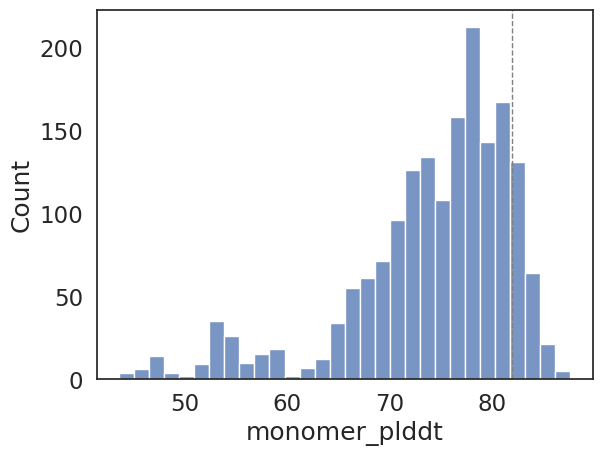

In [166]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

# Define the working directory and load the CSV file
scratch_dir = "/net/scratch/achen918/cleave_real_targets/251222_tdp43_large_batch"
working_dir = scratch_dir + "/af3_monomer_analysis/folding_out"
combined_csv_file = os.path.join(working_dir, "af3_data.csv")
filtered_csv_file = os.path.join(working_dir, "af3_folding_filtered.csv")
df = pd.read_csv(combined_csv_file , sep=',')

x_point = 82

# Convert columns to numeric, coerce errors if there are any invalid values
df['monomer_plddt'] = pd.to_numeric(df['monomer_plddt'], errors='coerce')


g = sns.histplot(data=df, x='monomer_plddt')
g.axvline(x=x_point, color='gray', linestyle='dashed', linewidth=1)

# Count filtered output with additional conditions for RMSD values
condition = (
    (df['monomer_plddt'] > x_point) 
)
satisfying_df = df[condition]
count = satisfying_df.shape[0]
print(f'Number of outputs satisfying filter: {count} out of {len(df)} predictions' )
print(f"fraction of outputs satisfying filter: {count/len(df)}")
satisfying_df.to_csv(filtered_csv_file)

## RMSD to rfd3 design models

In [167]:
import os
import pandas as pd
import math
def generate_slurm_script(input_csv, template_pdb_dir, output_dir, log_dir, num_tasks, time, mem, rmsd_script, cif2pdb_script):
    slurm_script = f"""#!/bin/bash
#SBATCH -p cpu
#SBATCH --mem={mem}
#SBATCH -c 1
#SBATCH -J calculate_geometry
#SBATCH -o {log_dir}/process_data_%A_%a.out
#SBATCH -t {time}
#SBATCH -a 0-{num_tasks-1}

# Set variables
INPUT_CSV="{input_csv}"
TEMPLATE_PDB_DIR="{template_pdb_dir}"
OUTPUT_DIR="{output_dir}"

# Calculate chunk size and indices
TOTAL_ROWS=$(wc -l < "$INPUT_CSV")
CHUNK_SIZE=$(( (TOTAL_ROWS + SLURM_ARRAY_TASK_COUNT - 1) / SLURM_ARRAY_TASK_COUNT ))
START_INDEX=$(( SLURM_ARRAY_TASK_ID * CHUNK_SIZE ))
END_INDEX=$(( START_INDEX + CHUNK_SIZE ))

# Ensure END_INDEX doesn't exceed TOTAL_ROWS
if [ $END_INDEX -gt $TOTAL_ROWS ]; then
    END_INDEX=$TOTAL_ROWS
fi

# Run the Python script
/software/containers/PPI_design.sif {cif2pdb_script} "$INPUT_CSV" $START_INDEX $END_INDEX
/software/containers/PPI_design.sif {rmsd_script} "$INPUT_CSV" "$TEMPLATE_PDB_DIR" "${{OUTPUT_DIR}}/output_${{SLURM_ARRAY_TASK_ID}}.csv" $START_INDEX $END_INDEX
"""
    return slurm_script

def main():
    
    slurm_script = generate_slurm_script(
        input_csv,
        template_pdb_dir,
        output_dir,
        log_dir,
        num_tasks,
        time,
        mem,
        rmsd_script,
        cif2pdb_script
    )

    with open(output_slurm, "w") as f:
        f.write(slurm_script)

    print(f"SLURM script generated: {output_slurm}")
    print("You can now submit the job with:")
    print(f"sbatch {output_slurm}")

if __name__ == "__main__":
    scratch_dir = "/net/scratch/achen918/cleave_real_targets/251222_tdp43_large_batch"
    working_directory  = scratch_dir + "/af3_monomer_analysis"
    input_csv = f'{working_directory}/folding_out/af3_folding_filtered.csv' 
    template_pdb_dir = scratch_dir + "/filter_bb/filtered_bbs/" 
            
    log_dir = f'{working_directory}/log_catalytic_site_geometry' 
    os.makedirs(log_dir, exist_ok=True)
    output_dir = working_directory + '/rmsd_calculation_output'
    os.makedirs(output_dir , exist_ok=True)
    
    rows_per_task = 500
    num_tasks=math.ceil(len(pd.read_csv(input_csv))/rows_per_task)
    time='02:00:00'
    mem='1g' 
    rmsd_script = f'{os.getcwd()}/af3_monomer_analysis/rmsd_calculation.py' 
    cif2pdb_script = f'{os.getcwd()}/af3_monomer_analysis/convert_modify_pdb.py'
    output_slurm = f'{os.getcwd()}/af3_monomer_analysis/run_array_job_rmsd_calculation.sh' 
    
    main()

SLURM script generated: /home/achen918/cleave_real_targets/251222_tdp43_large_batch/af3_monomer_analysis/run_array_job_rmsd_calculation.sh
You can now submit the job with:
sbatch /home/achen918/cleave_real_targets/251222_tdp43_large_batch/af3_monomer_analysis/run_array_job_rmsd_calculation.sh


In [168]:
## concatenate results
rmsd_csv_path = "/net/scratch/achen918/cleave_real_targets/251222_tdp43_large_batch/af3_monomer_analysis/" + os.path.basename(input_csv).split('.csv')[0]+'_distance_rmsd_calculated.csv'
concatenating_command = f"cat {output_dir}/output_*.csv > {rmsd_csv_path}"
print('concatenate all processed csv files:\n',concatenating_command)
print('\nIf you see *~ files, simply check the .csv file and do rm *~')

concatenate all processed csv files:
 cat /net/scratch/achen918/cleave_real_targets/251222_tdp43_large_batch/af3_monomer_analysis/rmsd_calculation_output/output_*.csv > /net/scratch/achen918/cleave_real_targets/251222_tdp43_large_batch/af3_monomer_analysis/af3_folding_filtered_distance_rmsd_calculated.csv

If you see *~ files, simply check the .csv file and do rm *~


In [172]:

def get_descriptions_with_at_least_n_passes(df, condition, n=3):
    """
    Identify unique 'definition' values in the DataFrame that have at least `n` rows 
    satisfying `condition` among the 5 predictions per definition.

    Parameters:
        df (pd.DataFrame): The input DataFrame containing 'definition' and 'pdb_path' columns.
        condition (pd.Series): A boolean Series indicating which rows satisfy the condition.
        n (int): Minimum number of passing predictions required per definition.

    Returns:
        List[str]: A list of 'definition' values meeting the criteria.
    """
    # Combine df with condition into a single DataFrame with a boolean column for easier grouping
    df = df.copy()
    df['pass_condition'] = condition

    # Group by 'description' and count how many rows pass the condition in each group
    passing_counts = df.groupby('description')['pass_condition'].sum()

    # Select descriptions where the number of passing predictions >= n
    qualified_descriptions = passing_counts[passing_counts >= n].index.tolist()

    return qualified_descriptions

def extract_template(description, remove_trailing_index=1):
    """
    Extract the base '..._model_<n>' part from a description string.
    Handles both timestamped and non-timestamped folders, any model number, 
    and any trailing replicate index.
    """
    # 1. Remove timestamp suffix _YYYYMMDD_HHMMSS
    desc = re.sub(r"_\d{8}_\d{6}$", "", description)
    
    if remove_trailing_index==1:
        # 2. Remove trailing replicate index (e.g., _1, _2, etc.)
        desc = re.sub(r"_\d+$", "", desc)
    
    # 3. Extract everything up to and including ..._model_<number>
    m = re.search(r"(.*_model_\d+)$", desc)
    if m:
        return m.group(1)
    return desc  # fallback if regex fails

In [178]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import re

csv_monomer = "/net/scratch/achen918/cleave_real_targets/251222_tdp43_large_batch/af3_monomer_analysis//af3_folding_filtered_distance_rmsd_calculated.csv"
df_monomer = pd.read_csv(csv_monomer)
df = df_monomer.copy()

## check unique mpnn seqs
df['mpnn_seq_name'] = df['description'].apply(lambda x: extract_template(x, remove_trailing_index=0))
df['diffusion_bb'] = df['description'].apply(extract_template)

df['monomer_plddt'] = pd.to_numeric(df['monomer_plddt'], errors='coerce')
df = df.dropna(subset=['monomer_plddt'], how='any')

for column in ['monomer_plddt', 'all_res_ca_rmsd', 'cata_res_sc_rmsd', 'cata_res_bb_rmsd']:
    df[column] = df[column].astype(float)

monomer_plddt_thresh = 85
all_res_ca_rmsd_thresh = 1.2
cata_res_sc_rmsd_thresh = 1.5

    
condition = (df['monomer_plddt']> monomer_plddt_thresh) &\
                (df['all_res_ca_rmsd']<all_res_ca_rmsd_thresh) &\
                (df['cata_res_sc_rmsd']<cata_res_sc_rmsd_thresh )

## print number of predictions and chai seqs that pass filter
print(f"{len(df[condition])} predictions pass filter, {len(df[condition].mpnn_seq_name.unique())} mpnn seqs pass filter")
print(f" {len(df[condition].diffusion_bb.unique())} diffusion_bbs pass filter")

df_monomer_pass = df[condition].copy()
df_monomer_all = df.copy()

# Suppose `df` is your DataFrame and `condition` is your boolean Series (e.g., df['score'] > 0.7)
requested_num_passes = 2
qualified_defs_monomer = get_descriptions_with_at_least_n_passes(df, condition, n=requested_num_passes)
print(f"Number of qualified descriptions with {requested_num_passes} out of 5 passes: {len(qualified_defs_monomer)}")


1 predictions pass filter, 1 mpnn seqs pass filter
 1 diffusion_bbs pass filter
Number of qualified descriptions with 2 out of 5 passes: 0


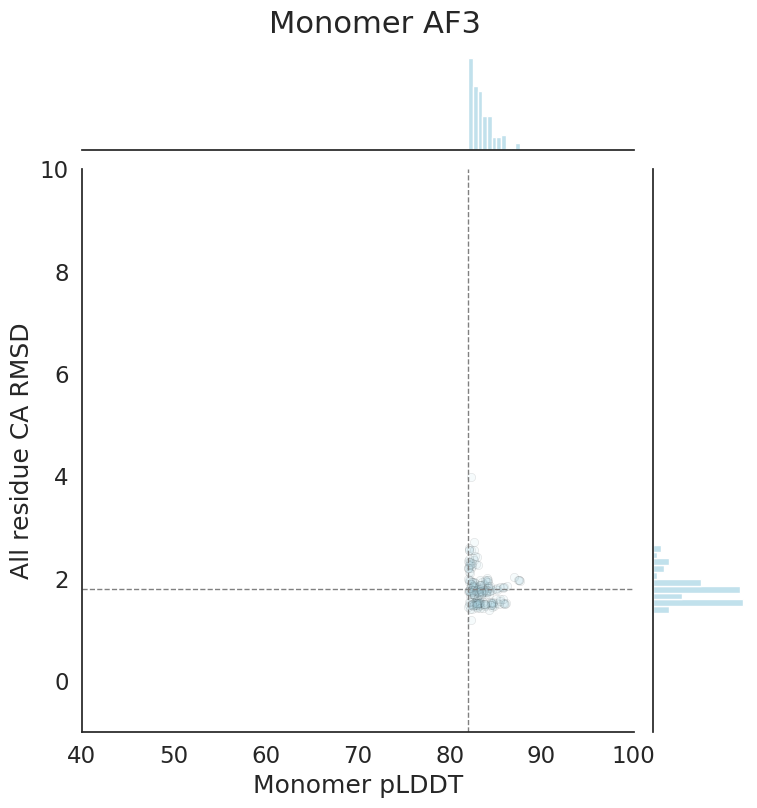

number of predictions satisfying constraints:
117
Number of unique diffusion bbs :
10


In [184]:

# Convert columns to numeric, coerce errors if there are any invalid values

# df = df[df.description.apply(lambda x: "qaqkqaq" in x.lower())]
x_point = 82
y_point = 1.8 ## 

# Set style
sns.set(style="white", font_scale=1.5)

# Create jointplot
g = sns.jointplot(
    data=df, 
    x='monomer_plddt', 
    y='cata_res_sc_rmsd', 
    kind='scatter', 
    color='lightblue', 
    edgecolor='black', 
    alpha=0.1,
    height=8,  # Size of the figure
)

# Add vertical and horizontal lines
g.ax_joint.axvline(x=x_point , color='gray', linestyle='dashed', linewidth=1)
g.ax_joint.axhline(y=y_point , color='gray', linestyle='dashed', linewidth=1)

# Set axis limits
g.ax_joint.set_xlim([40, 100])
g.ax_joint.set_ylim([-1, 10])

# Set labels and title
g.set_axis_labels('Monomer pLDDT', 'All residue CA RMSD', fontsize=18)
g.fig.suptitle('Monomer AF3', y=1.02, fontsize=22)

plt.show()

# Count filtered output with additional conditions for RMSD values
condition = (
    (df['monomer_plddt'] > x_point) &
    (df['cata_res_sc_rmsd'] < y_point) 
)

print("number of predictions satisfying constraints:")
print(len(df[condition]))
print("Number of unique diffusion bbs :")
print(df[condition]['diffusion_bb'].nunique())
bb_passing_monomer = df[condition]['diffusion_bb'].unique()


# AF3 complex for AF3 monomer passes

In [188]:
import os
import glob
import json
from Bio.PDB import MMCIFParser
from Bio.PDB import PDBParser
import re



# Amino acid mapping from 3-letter to 1-letter code
aa_map = {
    "ALA": "A", "ARG": "R", "ASN": "N", "ASP": "D", "CYS": "C",
    "GLN": "Q", "GLU": "E", "GLY": "G", "HIS": "H", "ILE": "I",
    "LEU": "L", "LYS": "K", "MET": "M", "PHE": "F", "PRO": "P",
    "SER": "S", "THR": "T", "TRP": "W", "TYR": "Y", "VAL": "V"
}


def extract_sequence_from_pdb(pdb_file, chain_id):
    """Extracts the sequence of a given chain from a PDB file."""
    sequence = []
    seen_residues = set()

    with open(pdb_file, 'r') as file:
        for line in file:
            if line.startswith("ATOM") and line[21] == chain_id:  # Column 22 is Chain ID
                res_name = line[17:20].strip()  # Column 18-20 is Residue Name
                res_id = line[22:26].strip()    # Column 23-26 is Residue Number
                
                if (res_id not in seen_residues) and (res_name in aa_map):
                    seen_residues.add(res_id)
                    sequence.append(aa_map[res_name])
    
    return "".join(sequence)


# Define directories

scratch_dir = "/net/scratch/achen918/cleave_real_targets/251222_tdp43_large_batch"
working_dir = scratch_dir + "/af3_complex"
input_dir = scratch_dir + "/enhanced_mpnn/enhanced_mpnn_output/*/backbones/" # all mpnn seqs are used
json_dir = f'{working_dir}/json_files'
output_dir = working_dir + '/output'
command_file_path = os.path.join(working_dir, "cmds_af3_complex")

# Ensure directories exist
os.makedirs(working_dir, exist_ok=True)
os.makedirs(json_dir, exist_ok=True)
os.makedirs(output_dir, exist_ok=True)


# Collect PDB info
pdb_files = glob.glob(os.path.join(input_dir, "*.pdb"))
pdb_data_list = []

print(f"total number of pdb_files is {len(pdb_files)}")

for pdb_file in pdb_files:
    pdb_name = os.path.splitext(os.path.basename(pdb_file))[0]

    if pdb_name.lower() in df[condition]["mpnn_seq_name"].unique():

        chain_A_seq = extract_sequence_from_pdb(pdb_file, "A")
        chain_B_seq = re.sub(r"\d+", "", pdb_name.split("_")[0]).upper()
        
        # chain_B_seq = extract_sequence_from_pdb(pdb_file, "B")
        total_len = len(chain_A_seq) + len(chain_B_seq) +2 ## 2 is for ZnO

        pdb_data_list.append({
            "pdb_name": pdb_name,
            "chain_A_seq": chain_A_seq,
            "chain_B_seq": chain_B_seq,
            "total_len": total_len
        })

from collections import defaultdict

# ============================
# USER-DEFINED GROUP SIZE
# ============================
GROUP_SIZE = 200   # <–– change this as needed

# ============================
# Group PDBs by identical length
# ============================
length_groups = defaultdict(list)
for pdb_data in pdb_data_list:
    length_groups[pdb_data["total_len"]].append(pdb_data)

# ============================
# Write JSONs + commands
# ============================
with open(command_file_path, 'w') as cmd_file:

    for length, pdbs_same_len in sorted(length_groups.items()):

        # chunk into GROUP_SIZE pieces
        for part_idx in range(0, len(pdbs_same_len), GROUP_SIZE):
            chunk = pdbs_same_len[part_idx : part_idx + GROUP_SIZE]

            # Build JSON list
            group_json = []
            for pdb_data in chunk:
                group_json.append({
                    "name": pdb_data["pdb_name"],
                    "sequences": [
                        {"protein": {"id": "A", "sequence": pdb_data["chain_A_seq"],
                                     "unpairedMsa": "", "pairedMsa": "", "templates": ""}},
                        {"protein": {"id": "B", "sequence": pdb_data["chain_B_seq"],
                                     "unpairedMsa": "", "pairedMsa": "", "templates": ""}},
                        {"ligand":{"id":"C","smiles":"[Zn+2].O"}}
                    ],
                    "modelSeeds": [1],
                    "dialect": "alphafold3",
                    "version": 3
                })

            # Generate JSON filename
            group_name = f"group_len{length}_part{part_idx//GROUP_SIZE + 1}.json"
            json_file_path = os.path.join(json_dir, group_name)

            # Write JSON
            with open(json_file_path, "w") as f_json:
                json.dump(group_json, f_json, separators=(",", ":"))

            # Write sbatch command
            cmd = f"""
###CMD###
#!/bin/bash

echo "Running AlphaFold3 prediction for length {length}, batch part {part_idx//GROUP_SIZE + 1}..."
/software/containers/users/ikalvet/mlfold3/mlfold3_01.sif python \
/home/achen918/software/run_alphafold_custom.py \  
        --json_path="{json_file_path}" \
        --output_dir="{output_dir}" \
        --run_data_pipeline=False \
        --buckets {length}
"""
            cmd_file.write(cmd)

        print(
            f"Created {len(pdbs_same_len)} PDBs of length {length}, "
            f"{(len(pdbs_same_len)-1)//GROUP_SIZE + 1} groups"
        )

print(f"All commands saved to {command_file_path}")



total number of pdb_files is 610
Created 5 PDBs of length 190, 1 groups
Created 2 PDBs of length 192, 1 groups
Created 15 PDBs of length 197, 1 groups
Created 3 PDBs of length 201, 1 groups
Created 5 PDBs of length 202, 1 groups
All commands saved to /net/scratch/achen918/cleave_real_targets/251222_tdp43_large_batch/af3_complex/cmds_af3_complex


In [189]:
# Define the SLURM job script parameters

scratch_dir = "/net/scratch/achen918/cleave_real_targets/251222_tdp43_large_batch" 
working_dir = scratch_dir + "/af3_complex"

command_file_path = working_dir + "/cmds_af3_complex"
log_dir = os.path.join(working_dir, "log")
# Create a log directory inside the working directory (if not exists)
# os.makedirs(log_dir, exist_ok=True)

group_size = 1  # Set your group size here

# Count actual commands using bash script markers
with open(command_file_path, 'r') as cmd_file:
    total_commands = 0
    in_command = False
    for line in cmd_file:
        if line.startswith('#!/bin/bash'):
            total_commands += 1
            in_command = True
        elif in_command and line.strip() == 'fi':
            in_command = False

# Calculate the job array range
job_array_range = total_commands // group_size + (1 if total_commands % group_size != 0 else 0)


# Define the SLURM job script parameters
slurm_script_path = os.path.join(working_dir, "submit_af3.sh")

# Generate the SLURM script
slurm_script = f"""#!/bin/bash
#SBATCH --mail-type=BEGIN
#SBATCH --mail-type=END
#SBATCH --mail-user=achen918
#SBATCH -p gpu-bf
#SBATCH --gres=gpu:1
#SBATCH -c 2
#SBATCH --mem=16G
#SBATCH -t 2:00:00
#SBATCH -o {log_dir}/q%a.log
#SBATCH -a 1-{job_array_range}
#SBATCH --exclude=g1103,g1104,g1105,g1106,g1107,g1108,g1109,g1110,g1111,g1112,g1113,g1114,g1115,g1116,g1117,g1118,g1119,g1120,g1121,g1122,g1123,g1124,g2117,g2702,g2703,g2705


GROUP_SIZE={group_size}

for I in $(seq 1 $GROUP_SIZE)
do
    J=$(($SLURM_ARRAY_TASK_ID * $GROUP_SIZE + $I - $GROUP_SIZE))
    
    # Extract command block using awk
    CMD=$(awk -v cmd_num="$J" '
        /^###CMD###/ {{ if (++count == cmd_num) {{ flag=1; next }} }}
        flag {{ if (/^###CMD###/) {{ flag=0 }} else {{ print }} }}
    ' {command_file_path})
    
    if [ -n "$CMD" ]; then
        echo "Running command $J:"
        echo "$CMD" | bash
    fi
done
"""

# Write the SLURM script to a file
with open(slurm_script_path, 'w') as slurm_file:
    slurm_file.write(slurm_script)

print(f"SLURM submit script saved at: {slurm_script_path}")

SLURM submit script saved at: /net/scratch/achen918/cleave_real_targets/251222_tdp43_large_batch/af3_complex/submit_af3.sh


# AF3 complex analysis

## Collect folding metrics and interface quality metrics

In [191]:
import argparse
import os
import math
import glob

def create_slurm_script(script_path, output_act_dir, input_json_dir, combined_output_file, num_jobs, pdbs_per_job, log_dir):
    script = f"""#!/bin/bash
#SBATCH -p cpu
#SBATCH --mem=4g
#SBATCH -c 1
#SBATCH -J collect_data_job
#SBATCH -o {log_dir}/out.log%a
#SBATCH -t 01:00:00
#SBATCH -a 1-{num_jobs}

# Create a directory for individual CSV outputs
output_dir="{log_dir}/../parallel_csvs"
mkdir -p $output_dir


# Calculate start and end indices for this job
start_idx=$(( ($SLURM_ARRAY_TASK_ID - 1) * {pdbs_per_job} + 1 ))
end_idx=$(( $SLURM_ARRAY_TASK_ID * {pdbs_per_job} ))

# Run the Python script with the calculated indices
/software/containers/PPI_design.sif {script_path} "{output_act_dir}" "{input_json_dir}" $start_idx $end_idx "$output_dir/output_$SLURM_ARRAY_TASK_ID.csv"
"""
    return script

def main():
    scratch_dir = "/net/scratch/achen918/cleave_real_targets/251222_tdp43_large_batch"
    working_dir = scratch_dir + "/af3_complex_analysis"
    combined_output_file = os.path.join(working_dir, 'af3_data.csv')
    output_act_dir = os.path.join(scratch_dir, 'af3_complex/output')
    input_json_dir = os.path.join(scratch_dir, 'af3_complex/json_files')
    
    log_dir = os.path.join(working_dir, "folding_out/logs")
    os.makedirs(log_dir, exist_ok=True)

    # Path to the Python script (collect_data.py)
    script_path = os.path.join(os.getcwd() + "/af3_complex_analysis", "collect_data.py")

    # Count total number of PDB files (one per folder in output_act_dir)
    num_pdbs = len([d for d in os.listdir(output_act_dir) if os.path.isdir(os.path.join(output_act_dir, d))])
    
    pdbs_per_job = 1000  # Change this value based on clusterstatus cpu usage, around 20 s/100 pdbs
    num_jobs = math.ceil(num_pdbs / pdbs_per_job)

    print(f"Found {num_pdbs} PDB folders. Splitting into {num_jobs} jobs with {pdbs_per_job} PDBs per job.")

    slurm_script_content = create_slurm_script(
        script_path=script_path,
        output_act_dir=output_act_dir,
        input_json_dir=input_json_dir, 
        combined_output_file=combined_output_file,
        num_jobs=num_jobs,
        pdbs_per_job=pdbs_per_job,
        log_dir=log_dir,
    )

    submit_script_path = os.path.join(os.getcwd() + "/af3_complex_analysis", "submit_collect_data.sh")
    
    with open(submit_script_path, "w") as f:
        f.write(slurm_script_content)

    print(f"SLURM submit script written to: {submit_script_path}")
    print(f"Submit your job with: sbatch {submit_script_path}")

main()


Found 30 PDB folders. Splitting into 1 jobs with 1000 PDBs per job.
SLURM submit script written to: /home/achen918/cleave_real_targets/251222_tdp43_large_batch/af3_complex_analysis/submit_collect_data.sh
Submit your job with: sbatch /home/achen918/cleave_real_targets/251222_tdp43_large_batch/af3_complex_analysis/submit_collect_data.sh


In [193]:
import os

scratch_dir = "/net/scratch/achen918/cleave_real_targets/251222_tdp43_large_batch/"
working_dir = scratch_dir + "/af3_complex_analysis/folding_out"

# Define paths
parallel_csv_dir = os.path.join(working_dir, "parallel_csvs")
combined_csv_file = os.path.join(working_dir, "af3_data.csv")

# Combine all individual CSV files into one, removing redundant headers
os.system(f"head -n 1 {parallel_csv_dir}/output_1.csv > {combined_csv_file}")  # Add header from the first file ## not output_2.csv for some reason... (?)
os.system(f"tail -n +2 -q {parallel_csv_dir}/output_*.csv >> {combined_csv_file}")  # Append data from all files, skipping headers

print(f"Combined CSV written to: {combined_csv_file}")


Combined CSV written to: /net/scratch/achen918/cleave_real_targets/251222_tdp43_large_batch//af3_complex_analysis/folding_out/af3_data.csv


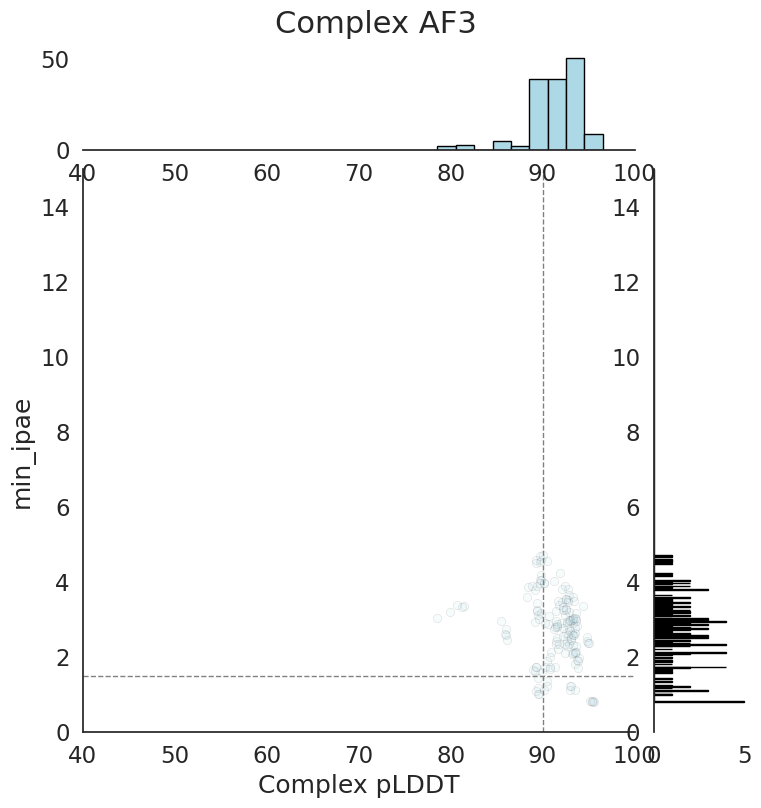

Number of outputs satisfying filter: 12 out of 150 predictions
fraction of outputs satisfying filter: 0.08


In [196]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

# Define the working directory and load the CSV file
scratch_dir = "/net/scratch/achen918/cleave_real_targets/251222_tdp43_large_batch"
working_dir = scratch_dir + "/af3_complex_analysis/folding_out"
combined_csv_file = os.path.join(working_dir, "af3_data.csv")
filtered_csv_file = os.path.join(working_dir, "af3_folding_filtered.csv")
df = pd.read_csv(combined_csv_file , sep=',')
## check unique mpnn seqs
df['mpnn_seq_name'] = df['description'].apply(lambda x: x.removeprefix('pred.').split('_seed')[0])
df['diffusion_bb'] = df['mpnn_seq_name'].apply(lambda x: x.split("-atomized-bb-false")[0])

# Convert columns to numeric, coerce errors if there are any invalid values
df['complex_plddt'] = pd.to_numeric(df['complex_plddt'], errors='coerce')
df['ipae_min'] = pd.to_numeric(df['ipae_min'], errors='coerce')
# df = df[df.description.apply(lambda x: "qaqkqaq" in x.lower())]
x_point = 90
y_point = 2 ## 

# Set style
sns.set(style="white", font_scale=1.5)

# Create jointplot
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
# Your original jointplot
g = sns.jointplot(
    data=df, 
    x='complex_plddt', 
    y='ipae_min', 
    kind='scatter', 
    color='lightblue', 
    edgecolor='black', 
    alpha=0.1,
    height=8,
)

# Calculate custom bin edges
x_min, x_max = df['complex_plddt'].min(), df['complex_plddt'].max()
y_min, y_max = df['ipae_min'].min(), 15
x_bins = np.arange(x_min, x_max + 2, 2)
y_bins = np.arange(y_min, y_max + 0.02, 0.02)

# Redraw marginal histograms with specified bins
g.ax_marg_x.clear()
g.ax_marg_x.hist(df['complex_plddt'], bins=x_bins, color='lightblue', edgecolor='black')
g.ax_marg_y.clear()
g.ax_marg_y.hist(df['ipae_min'], bins=y_bins, color='lightblue', edgecolor='black', orientation='horizontal')



# Add vertical and horizontal lines
g.ax_joint.axvline(x=x_point , color='gray', linestyle='dashed', linewidth=1)
g.ax_joint.axhline(y=y_point , color='gray', linestyle='dashed', linewidth=1)

# Set axis limits
g.ax_joint.set_xlim([40, 100])
g.ax_joint.set_ylim([0, 15])

# Set labels and title
g.set_axis_labels('Complex pLDDT', 'min_ipae', fontsize=18)
g.fig.suptitle('Complex AF3', y=1.02, fontsize=22)

plt.show()

# Count filtered output with additional conditions for RMSD values
condition = (
    (df['complex_plddt'] > x_point) &
    (df['ipae_min'] < y_point) 
)
satisfying_df = df[condition]
count = satisfying_df.shape[0]
print(f'Number of outputs satisfying filter: {count} out of {len(df)} predictions' )
print(f"fraction of outputs satisfying filter: {count/len(df)}")
satisfying_df.to_csv(filtered_csv_file)


## Catalytic site geometry

In [200]:
import os
import pandas as pd
import math
def generate_slurm_script(input_csv, template_pdb_dir,  output_dir, log_dir, num_tasks, time, mem, rmsd_script, cif2pdb_script):
    slurm_script = f"""#!/bin/bash
#SBATCH -p cpu
#SBATCH --mem={mem}
#SBATCH -c 1
#SBATCH -J calculate_geometry
#SBATCH -o {log_dir}/process_data_%A_%a.out
#SBATCH -t {time}
#SBATCH -a 0-{num_tasks-1}

# Set variables
INPUT_CSV="{input_csv}"
TEMPLATE_PDB_DIR="{template_pdb_dir}"
OUTPUT_DIR="{output_dir}"

# Calculate chunk size and indices
TOTAL_ROWS=$(wc -l < "$INPUT_CSV")
CHUNK_SIZE=$(( (TOTAL_ROWS + SLURM_ARRAY_TASK_COUNT - 1) / SLURM_ARRAY_TASK_COUNT ))
START_INDEX=$(( SLURM_ARRAY_TASK_ID * CHUNK_SIZE ))
END_INDEX=$(( START_INDEX + CHUNK_SIZE ))

# Ensure END_INDEX doesn't exceed TOTAL_ROWS
if [ $END_INDEX -gt $TOTAL_ROWS ]; then
    END_INDEX=$TOTAL_ROWS
fi

# Run the Python script
/software/containers/PPI_design.sif {cif2pdb_script} "$INPUT_CSV" $START_INDEX $END_INDEX
/software/containers/PPI_design.sif {rmsd_script} "$INPUT_CSV" "$TEMPLATE_PDB_DIR" "${{OUTPUT_DIR}}/output_${{SLURM_ARRAY_TASK_ID}}.csv" $START_INDEX $END_INDEX
"""
    return slurm_script

def main():
    
    slurm_script = generate_slurm_script(
        input_csv,
        template_pdb_dir,
        output_dir,
        log_dir,
        num_tasks,
        time,
        mem,
        rmsd_script,
        cif2pdb_script
    )

    with open(output_slurm, "w") as f:
        f.write(slurm_script)

    print(f"SLURM script generated: {output_slurm}")
    print("You can now submit the job with:")
    print(f"sbatch {output_slurm}")

if __name__ == "__main__":
   
    scratch_dir = "/net/scratch/achen918/cleave_real_targets/251222_tdp43_large_batch"
    working_directory = scratch_dir + "/af3_complex_analysis/"
    input_csv = f'{working_directory}/folding_out/af3_folding_filtered.csv' 
    template_pdb_dir = scratch_dir + "/filter_bb/filtered_bbs"
            
    log_dir = f'{working_directory}/log_catalytic_site_geometry' 
    os.makedirs(log_dir, exist_ok=True)
    output_dir = working_directory + '/rmsd_calculation_output'
    os.makedirs(output_dir , exist_ok=True)
    
    rows_per_task = 200
    num_tasks=math.ceil(len(pd.read_csv(input_csv))/rows_per_task)
    time='02:00:00'
    mem='1g' 
    rmsd_script = f'{os.getcwd()}/af3_complex_analysis/rmsd_calculation.py' 
    cif2pdb_script = f'{os.getcwd()}/af3_complex_analysis/convert_modify_pdb.py'
    output_slurm = f'{os.getcwd()}/af3_complex_analysis/run_array_job_rmsd_calculation.sh' 
    
    main()

### Concatenate results

SLURM script generated: /home/achen918/cleave_real_targets/251222_tdp43_large_batch/af3_complex_analysis/run_array_job_rmsd_calculation.sh
You can now submit the job with:
sbatch /home/achen918/cleave_real_targets/251222_tdp43_large_batch/af3_complex_analysis/run_array_job_rmsd_calculation.sh


In [202]:
scratch_dir = "/net/scratch/achen918/cleave_real_targets/251222_tdp43_large_batch/"
rmsd_csv_path =scratch_dir + "/af3_complex_analysis/" + os.path.basename(input_csv).split('.csv')[0]+'_distance_rmsd_calculated.csv'
concatenating_command = f"cat {output_dir}/output_*.csv > {rmsd_csv_path}"
print('concatenate all processed csv files:\n',concatenating_command)
print('\nIf you see *~ files, simply check the .csv file and do rm *~')

concatenate all processed csv files:
 cat /net/scratch/achen918/cleave_real_targets/251222_tdp43_large_batch/af3_complex_analysis//rmsd_calculation_output/output_*.csv > /net/scratch/achen918/cleave_real_targets/251222_tdp43_large_batch//af3_complex_analysis/af3_folding_filtered_distance_rmsd_calculated.csv

If you see *~ files, simply check the .csv file and do rm *~


In [203]:

def get_descriptions_with_at_least_n_passes(df, condition, n=3):
    """
    Identify unique 'definition' values in the DataFrame that have at least `n` rows 
    satisfying `condition` among the 5 predictions per definition.

    Parameters:
        df (pd.DataFrame): The input DataFrame containing 'definition' and 'pdb_path' columns.
        condition (pd.Series): A boolean Series indicating which rows satisfy the condition.
        n (int): Minimum number of passing predictions required per definition.

    Returns:
        List[str]: A list of 'definition' values meeting the criteria.
    """
    # Combine df with condition into a single DataFrame with a boolean column for easier grouping
    df = df.copy()
    df['pass_condition'] = condition

    # Group by 'description' and count how many rows pass the condition in each group
    passing_counts = df.groupby('description')['pass_condition'].sum()

    # Select descriptions where the number of passing predictions >= n
    qualified_descriptions = passing_counts[passing_counts >= n].index.tolist()

    return qualified_descriptions

In [223]:
import pandas as pd
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)
scratch_dir = "/net/scratch/achen918/cleave_real_targets/251222_tdp43_large_batch/"
csv_complex = scratch_dir + "/af3_complex_analysis//af3_folding_filtered_distance_rmsd_calculated.csv"
csv_complex = scratch_dir + "/af3_complex_analysis//af3_folding_filtered_distance_rmsd_calculated.csv"
df_complex = pd.read_csv(csv_complex)


## conditions for iterate phosphoTS mpnn:
pae_thresh = 5
ipae_min_thresh = 1.5
enzyme_plddt_thresh = 90
complex_plddt_thresh = 90
rmsd_zinc_chelation_thresh = 200
zinc_sub_thresh = 5 # astacin zinc hydroxide af3 is 3.6
zinc_sub_chel_thresh = 25 ## angle difference between astacin af3 and design, in astacin af3, three angles are  119.7 , 140.5,  95.6 . single sided. design angle has to be larger than ideal - thresh
three_angle_thresh = 250
three_dihedral_thresh = 250
ca_rmsd_thresh = 3
sc_rmsd_thresh = 1.5 ## this includes 3 his and glu, tyrosine
opening_angle_thresh = 40
glu_to_coC_sum_thresh = 200 # astacin af3 ES complex is 4.5 + 5.4 = 9.9
tyr_to_coO_thresh = 4 # native astacin af3 ES complex is 2.2 
leaving_N_glu_O_thresh = 4.3 ## native astacin af3 ES complex is 3.9
water_O_amide_plane_thresh = 15  # native is -86.5, very close to 90 C in astacin [Zn2+].O ES complex
water_O_CO_C_thresh = 2.9 # in native astacin this is 3.0
water_O_glu_base_thresh =200 # in native astacin this is 2.7 and 2.8
water_O_glu_base_steal_thresh = 3.0 # in native astacin this is 2.7 and 2.8
water_O_Zn_glu_C_CO_C_thresh = 43.1 # in native astacin this is 28.1 degrees
plddt_key_res_min_thresh = 90

### add a C-Zn-His angle filter as well 



df_complex['rmsd_zinc_chelation'] = pd.to_numeric(df_complex['rmsd_zinc_chelation'], errors='coerce')
df_complex = df_complex.dropna(subset=['rmsd_zinc_chelation'], how='any')
metrics = ['complex_plddt', 'per_chain_plddt_A',
       'per_chain_plddt_B', 'per_chain_plddt_C', 'plddt_key_res_min','ipae_min',
       'pae_interface', 'chainA_len', 'chainB_len', 'zinc_his0', 'zinc_his1',
       'zinc_glu_chel_O1', 'zinc_glu_chel_O2', 'co_glu_base_1', 'co_glu_base_2', 'zinc_sub',
       'co_tyr', 'water_O_CO_C', 'water_O_amide_plane','leaving_n_glu_1', 'leaving_n_glu_2', 'zinc_glu_chel_O',
       'water_O_glu_base_1', 'water_O_glu_base_2','water_O_glu_base_steal','water_O_Zn_glu_C_CO_C',
       'rmsd_zinc_chelation', 'leaving_n_glu', 'angle_zinc_his_0',
       'angle_zinc_his_1', 'angle_zinc_glu', 'three_angle_rmsd',
       'C_zinc_his_0', 'C_zinc_his_1', 'C_zinc_glu',
       'dihedral_zinc_his_0', 'dihedral_zinc_his_1', 'dihedral_zinc_glu',
       'three_dihedral_rmsd', 'ca_rmsd', 'sc_rmsd', 'largest_opening_angle']

for column in metrics:

    df_complex[column] = df_complex[column].astype(float)

condition = (df_complex['rmsd_zinc_chelation']<rmsd_zinc_chelation_thresh) & \
                (df_complex['pae_interface']<pae_thresh) & \
               (df_complex['ipae_min']<ipae_min_thresh) & \
                (df_complex['zinc_sub']<zinc_sub_thresh) #& \
            #     (df_complex['per_chain_plddt_A']>enzyme_plddt_thresh) & \
            # (df_complex['complex_plddt']>complex_plddt_thresh) & \
            # (df_complex['plddt_key_res_min']>plddt_key_res_min_thresh) & \
            # (df_complex['three_angle_rmsd']<three_angle_thresh) & \
            # (df_complex['three_dihedral_rmsd']<three_dihedral_thresh) &\
            # (df_complex['C_zinc_his_0'] >  119.7 - zinc_sub_chel_thresh ) &\
            # (df_complex['C_zinc_his_1'] > 140.5 - zinc_sub_chel_thresh ) &\
            # (df_complex['C_zinc_glu'] > 95.6 - zinc_sub_chel_thresh ) &\
            # (df_complex['ca_rmsd'] < ca_rmsd_thresh) &\
            # (df_complex['sc_rmsd'] < sc_rmsd_thresh) &\
            # (df_complex['largest_opening_angle'] > opening_angle_thresh) &\
            # (df_complex['co_glu_base_1'] + df_complex['co_glu_base_2'] < glu_to_coC_sum_thresh) &\
            # (df_complex['co_tyr'] < tyr_to_coO_thresh) &\
            # (df_complex['leaving_n_glu'] < leaving_N_glu_O_thresh) &\
            # (df_complex['water_O_CO_C'] < water_O_CO_C_thresh) &\
            # (df_complex['water_O_amide_plane'] > 86.5 - water_O_amide_plane_thresh) &\
            # (df_complex['water_O_amide_plane'] < 86.5 + water_O_amide_plane_thresh)  &\
            # (df_complex['water_O_glu_base_1'] < water_O_glu_base_thresh)  &\
            # (df_complex['water_O_glu_base_2'] < water_O_glu_base_thresh) &\
            # (df_complex['water_O_glu_base_steal'] < water_O_glu_base_steal_thresh) &\
            # (df_complex['water_O_Zn_glu_C_CO_C'] > -water_O_Zn_glu_C_CO_C_thresh) 


## check unique mpnn seqs
df_complex['mpnn_seq_name'] = df_complex['description'].apply(lambda x: x.split('_seed')[0])
df_complex['diffusion_bb'] = df_complex['mpnn_seq_name'].apply(lambda x: x.split("_packed_")[0])

## print number of predictions and chai seqs that pass filter
print(f"{len(df_complex[condition])} predictions pass filter, {len(df_complex[condition].mpnn_seq_name.unique())} mpnn seqs pass filter")
print(f" {len(df_complex[condition].diffusion_bb.unique())} diffusion_bbs pass filter")

df_complex_pass= df_complex[condition].copy()
df_complex_all = df_complex.copy()

# Suppose `df_complex` is your DataFrame and `condition` is your boolean Series (e.g., df_complex['score'] > 0.7)
require_num_pass = 2
qualified_defs_complex = get_descriptions_with_at_least_n_passes(df_complex, condition, n=require_num_pass)
print(f"Number of qualified descriptions with {require_num_pass} out of 5 passes: {len(qualified_defs_complex)}")


10 predictions pass filter, 2 mpnn seqs pass filter
 2 diffusion_bbs pass filter
Number of qualified descriptions with 2 out of 5 passes: 2


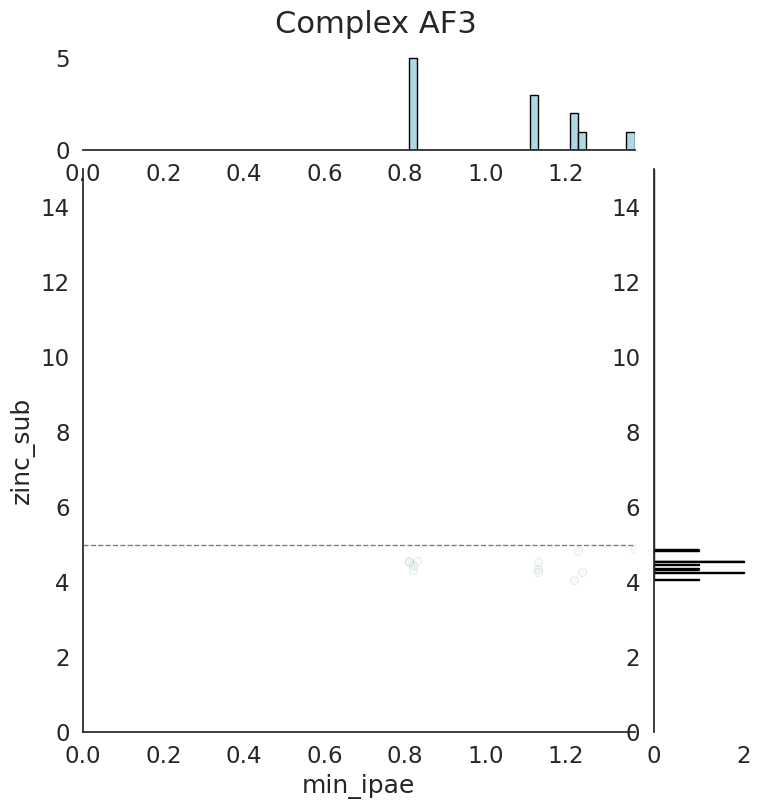

In [221]:
x = "ipae_min"
y = "zinc_sub"
x_point = 1.5
y_point = 5 ## 

# Set style
sns.set(style="white", font_scale=1.5)

# Create jointplot
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
# Your original jointplot
g = sns.jointplot(
    data=df_complex, 
    x='ipae_min', 
    y='zinc_sub', 
    kind='scatter', 
    color='lightblue', 
    edgecolor='black', 
    alpha=0.1,
    height=8,
)

# Calculate custom bin edges
x_min, x_max = df_complex['ipae_min'].min(), df_complex['ipae_min'].max()
y_min, y_max = df_complex['zinc_sub'].min(), 15
x_bins = np.arange(x_min, x_max +  0.02,  0.02)
y_bins = np.arange(y_min, y_max + 0.02, 0.02)

# Redraw marginal histograms with specified bins
g.ax_marg_x.clear()
g.ax_marg_x.hist(df_complex['ipae_min'], bins=x_bins, color='lightblue', edgecolor='black')
g.ax_marg_y.clear()
g.ax_marg_y.hist(df_complex['zinc_sub'], bins=y_bins, color='lightblue', edgecolor='black', orientation='horizontal')



# Add vertical and horizontal lines
g.ax_joint.axvline(x=x_point , color='gray', linestyle='dashed', linewidth=1)
g.ax_joint.axhline(y=y_point , color='gray', linestyle='dashed', linewidth=1)

# Set axis limits
g.ax_joint.set_xlim([0, x_max])
g.ax_joint.set_ylim([0, y_max])

# Set labels and title
g.set_axis_labels('min_ipae', 'zinc_sub', fontsize=18)
g.fig.suptitle('Complex AF3', y=1.02, fontsize=22)

plt.show()

# Recycle bbs for round 2